# Import libraries and set configs

In [ ]:
import sys
import os
import glob
import random
import warnings
import numpy as np
import pandas as pd
# import fireducks.pandas as pd
from os import environ
from datetime import datetime, timedelta
from tqdm.auto import tqdm

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.style as style
from dotenv import load_dotenv, find_dotenv

sys.path.append("..")
sys.path.append("../..")

# use matplotlib style
style.use("fivethirtyeight")

# here we load environment variables from .env, must be called before init. class
load_dotenv(find_dotenv('../.env'), verbose=True)

# Set environment variable
environ["ENV"] = "optimize"

tv_username = os.getenv("TV_USERNAME")
tv_password = os.getenv("TV_PASSWORD")

class CFG:
    # load new data from exchanges
    load = True
    # create dataset from zero
    create_dataset = True
    # update existing dataset
    update_dataset = True
    # TP and SL target ratio
    cls_target_ratio_tp = 1.05
    cls_target_ratio_sl = 1.05
    # last previous data point to collect for model training (value represents number of hours before signal point)
    last = 272
    # for how long time (in hours) we want to predict
    target_offset = 128
    # what trade types to use: buy, sell, both
    ttype = "both"
    patterns_to_filter = ["STOCH_RSI_Volume24"]
    # period to aggregate
    agg_periods = [24, 72]
    agg_funcs = [np.min, np.max, np.mean, np.median, np.std]

pd.set_option("display.max_columns", 500)
pd.set_option("display.max_rows", 500)

tqdm.pandas()

warnings.simplefilter(action="ignore", category=(FutureWarning, pd.errors.PerformanceWarning))

/home/alex/Repos/sigbot/.venv/lib/python3.12/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# from api.mexc_api import MEXC # !
# from ml.utils.reparation_utils import load_historical_data_from_exchange

# tickers = ["FWOGUSDT", "MEMEFIUSDT", "PORT3USDT", "BDXNUSDT", "LLUSDT", "CESUSDT", "SHXUSDT", "AGROUSDT", "VRUSDT", "UDSUSDT", "HOPPYUSDT", "CREOUSDT", "RIZUSDT", "QUAIUSDT", "XRPHUSDT", "ANYONEUSDT", "MLCUSDT", "MIUUSDT", "APEPEUSDT", "BDCAUSDT", "OKLOONUSDT", "NKEONUSDT", "RTXUSDT", "BLUEUSDT", "GMEONUSDT", "CONUSDT", "TAIXUSDT", "MASUSDT", "XELSUSDT", "PLBUSDT", "FUSDUSDT", "ACNUSDT", "TCOMUSDT", "VERDRAUSDT"]

# for ticker in tickers:
#     for timeframe in ["1h", "4h"]:
#         df = pd.read_pickle(f"data/tickers/{ticker}_{timeframe}.pkl")
#         ohlcv = ["open", "high", "low", "close", "volume", "funding_rate"]
#         df[ohlcv] = df[ohlcv].astype(float)
#         df.to_pickle(f"data/tickers/{ticker}_{timeframe}.pkl")

# mexc = MEXC()

# load_historical_data_from_exchange(mexc, tickers[26:])

In [ ]:
# import pandas as pd # !
# from pathlib import Path

# TICKERS_DIR = Path("data/tickers")
# SIGNAL_STAT_DIR = Path("data/signal_stat")

# bad_tickers = [
#     "FWOGUSDT", "MEMEFIUSDT", "PORT3USDT", "BDXNUSDT", "LLUSDT", "CESUSDT",
#     "SHXUSDT", "AGROUSDT", "VRUSDT", "UDSUSDT", "HOPPYUSDT", "CREOUSDT",
#     "RIZUSDT", "QUAIUSDT", "XRPHUSDT", "ANYONEUSDT", "MLCUSDT", "MIUUSDT",
#     "APEPEUSDT", "BDCAUSDT", "OKLOONUSDT", "NKEONUSDT", "RTXUSDT", "BLUEUSDT",
#     "GMEONUSDT", "CONUSDT", "TAIXUSDT", "MASUSDT", "XELSUSDT", "PLBUSDT",
#     "FUSDUSDT", "ACNUSDT", "TCOMUSDT", "VERDRAUSDT",
# ]

# for signal_file in ["buy_stat_1h.pkl", "sell_stat_1h.pkl", "train_buy_272.pkl", "train_sell_272.pkl"]:
#     signal_df = pd.read_pickle(SIGNAL_STAT_DIR / signal_file)
#     original_len = len(signal_df)

#     for ticker in bad_tickers:
#         ticker_path = TICKERS_DIR / f"{ticker}_1h.pkl"

#         ticker_times = pd.read_pickle(ticker_path)["time"]
#         valid_times = set(ticker_times)

#         mask = (signal_df["ticker"] == ticker) & (~signal_df["time"].isin(valid_times))
#         if mask.any():
#             print(f"{signal_file}: dropping {mask.sum()} rows for {ticker} with missing timestamps")
#             signal_df = signal_df[~mask]

#     print(f"{signal_file}: {original_len} -> {len(signal_df)} rows ({original_len - len(signal_df)} removed)")
#     signal_df.to_pickle(SIGNAL_STAT_DIR / signal_file)


buy_stat_1h.pkl: 85668 -> 85668 rows (0 removed)
sell_stat_1h.pkl: 85668 -> 85668 rows (0 removed)
train_buy_272.pkl: 71885 -> 71885 rows (0 removed)
train_sell_272.pkl: dropping 12 rows for FWOGUSDT with missing timestamps
train_sell_272.pkl: dropping 3 rows for MEMEFIUSDT with missing timestamps
train_sell_272.pkl: dropping 6 rows for PORT3USDT with missing timestamps
train_sell_272.pkl: dropping 5 rows for BDXNUSDT with missing timestamps
train_sell_272.pkl: dropping 2 rows for LLUSDT with missing timestamps
train_sell_272.pkl: dropping 3 rows for CESUSDT with missing timestamps
train_sell_272.pkl: dropping 14 rows for SHXUSDT with missing timestamps
train_sell_272.pkl: dropping 25 rows for VRUSDT with missing timestamps
train_sell_272.pkl: dropping 8 rows for UDSUSDT with missing timestamps
train_sell_272.pkl: dropping 1 rows for RIZUSDT with missing timestamps
train_sell_272.pkl: dropping 7 rows for QUAIUSDT with missing timestamps
train_sell_272.pkl: dropping 11 rows for ANYONEUS

In [ ]:
# import pandas as pd
# from pathlib import Path

# SIGNAL_STAT_DIR = Path("data/signal_stat")

# def remove_bad_signals(file_path, bad_signals):
#     if not bad_signals:
#         return
#     df = pd.read_pickle(file_path)
#     original_len = len(df)

#     bad_index = pd.MultiIndex.from_tuples(bad_signals, names=["ticker", "time"])
#     df_index = pd.MultiIndex.from_arrays([df["ticker"], df["time"]])
#     mask = df_index.isin(bad_index)

#     df = df[~mask]
#     print(f"{file_path.name}: {original_len} -> {len(df)} rows ({mask.sum()} removed)")
#     df.to_pickle(file_path)

# remove_bad_signals(SIGNAL_STAT_DIR / "buy_stat_1h.pkl", bad_buy_signals)
# remove_bad_signals(SIGNAL_STAT_DIR / "train_buy_272.pkl", bad_buy_signals)
# remove_bad_signals(SIGNAL_STAT_DIR / "sell_stat_1h.pkl", bad_sell_signals)
# remove_bad_signals(SIGNAL_STAT_DIR / "train_sell_272.pkl", bad_sell_signals)


# Load data

In [2]:
from ml.utils.ticker_loader import TickerLoader
from config.config import ConfigFactory

pattern = ["STOCH", "RSI", "Volume24"]
test_mode = False

configs = ConfigFactory.factory(environ).configs
configs["Higher_TF_indicator_list"] = ["Trend", "MACD"]
configs["Timeframes"]["work_timeframe"] = "1h"
configs["Timeframes"]["higher_timeframe"] = "4h"

if CFG.load:
    loader = TickerLoader(pattern, test_mode, **configs)
    min_time = datetime.now().replace(microsecond=0, second=0, minute=0) - pd.to_timedelta(365 * 10, unit="D")
    loader.load(min_time)
    for ttype in ["buy", "sell"]:
        print(f"Collect {ttype} stat")
        loader.collect_statistics(ttype, opt_limit=100000)

# Test loaded data

### Remove dataframe files with the biggest number of missing data

In [3]:
counter = 0 

tickers_1h = glob.glob("data/tickers/*_1h.pkl")
for ticker in tqdm(tickers_1h[3:]):
    df = pd.read_pickle(ticker)
    nunique = len(df["time"].diff()[1:].unique())
    if nunique > 1:
        count = df[df["time"].diff().astype("timedelta64[s]") != timedelta(hours=1)].shape[0]
        last_time = df["time"].iloc[-1]
        current_time = datetime.now()
        if count > 200 or (CFG.load and current_time - last_time > timedelta(hours=12)):
            print(ticker[:-7], nunique, count, last_time)
            os.remove(ticker)
            os.remove(ticker[:-6] + "4h.pkl")
            
counter

  0%|          | 0/4076 [00:00<?, ?it/s]

100%|██████████| 4076/4076 [00:02<00:00, 1938.67it/s]


0

### Plot time vs index for some of dataframe files

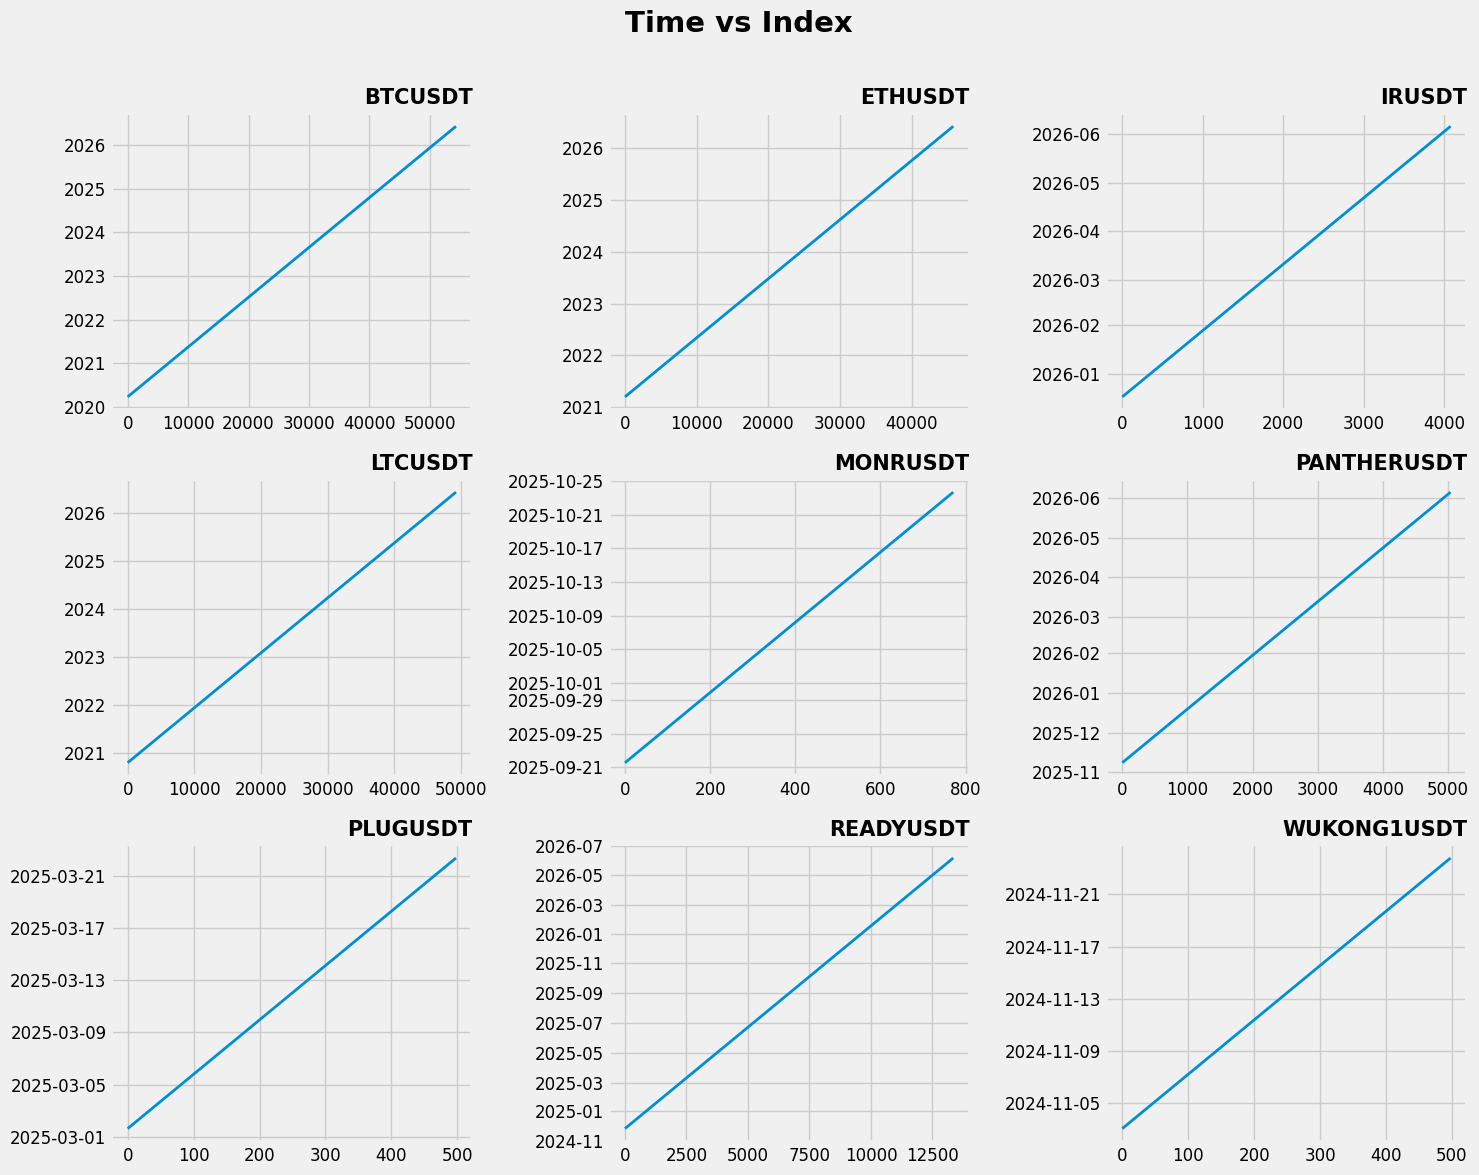

In [4]:
%matplotlib inline

n_cols = 3
n_rows = 3
figsize = (15, 4 * n_rows)

tickers = glob.glob("data/tickers/*_1h.pkl")
random_tickers = random.choices(tickers, k=n_cols*n_rows)
random_tickers[:3] = [t for t in tickers if "/BTCUSDT_1h" in t or "/ETHUSDT_1h" in t or "/LTCUSDT_1h" in t]

def plot_times(random_tickers, n_rows, n_cols):
    fig = plt.figure(figsize=figsize)
    
    for idx in range(n_cols*n_rows):
        ax = plt.subplot(n_rows, n_cols, idx + 1)
        
        df = pd.read_pickle(random_tickers[idx])
        sns.lineplot(data=df["time"])

        ax.set_ylabel("")
        plt.yticks(fontsize=12) 
        ax.set_xlabel("")
        plt.xticks(fontsize=12)
        # ax.spines["right"].set_visible(False)
        ax.set_title(f"{random_tickers[idx].split('/')[-1][:-7]}", loc="right", weight="bold", fontsize=15)
        ax.lines[0].set_linewidth(2)

    
    fig.suptitle("Time vs Index\n", ha="center",  fontweight="bold", fontsize=21)
    # fig.legend([1, 0], loc="upper center", bbox_to_anchor=(0.5, 0.96), fontsize=21, ncol=3)
    plt.tight_layout()
    plt.show()
    
plot_times(sorted(random_tickers),  n_rows=n_rows, n_cols=n_cols) 

### Check if all dataframe files has data for both timeframes 1h and 4h

If some haven't - remove them

In [5]:
import glob

x = glob.glob("data/tickers/*.pkl")
y = {i: i.split("USDT")[0] + "USDT" for i in x}
z = ("").join(x)

for k, v in y.items():
    if f"{v}_1h" not in z or f"{v}_4h" not in z:
        print(k)
        os.remove(k)

### Backup all important data files before continue

In [6]:
import shutil
from pathlib import Path

src = Path("data/signal_stat")
dst = src / "backup"
dst.mkdir(exist_ok=True)

for f in src.iterdir():
    if f.is_file():
        shutil.copy2(f, dst / f.name)

### Remove tickers that are in signal stat datasets but corresponding files are missing

In [7]:
from pathlib import Path

for ttype in ["buy", "sell"]:
    df = pd.read_pickle(f"data/signal_stat/{ttype}_stat_1h.pkl")

    for ticker in df["ticker"].unique():
        _ticker = ticker.replace("_", "")
        if not Path(f"data/tickers/{_ticker}_1h.pkl").exists() or not Path(f"data/tickers/{_ticker}_4h.pkl").exists() or ticker.endswith("_USDT"):
            df = df[df["ticker"] != ticker]
            print(f"Buy ticker doesn't exist {ticker}")

    df = df.reset_index(drop=True)
    df.to_pickle(f"data/signal_stat/{ttype}_stat_1h.pkl")

# Prepare and create train data

### Functions

In [8]:
from utils.data_utils import add_indicators, merge_btc_dominance, scale_cols

# Get configs
configs = ConfigFactory.factory(environ).configs

real_price_cols = ["real_high", "real_low", "real_close"]
funding_cols = ["funding_rate"]
btcd_cols = ["time", "btcd_open", "btcd_high", "btcd_low", "btcd_close", "btcd_volume"]
btcdom_cols = ["time", "btcdom_open", "btcdom_high", "btcdom_low", "btcdom_close", "btcdom_volume"]

def get_file(ticker):
    """ Find files buy ticker names """
    try:
        tmp_df_1h = pd.read_pickle(f"data/tickers/{ticker}_1h.pkl")
    except FileNotFoundError:
        print(f"File not found: {ticker}_1h.pkl")
        tmp_df_1h = None
    try:
        tmp_df_4h = pd.read_pickle(f"data/tickers/{ticker}_4h.pkl")
    except FileNotFoundError:
        print(f"File not found: {ticker}_4h.pkl")
        tmp_df_4h = None    
    return tmp_df_1h, tmp_df_4h

def create_train_df(df, btcd, btcdom, ttype, configs, target_offset, first, last, step, train_df_prev=None):
    """ Create train dataset from signal statistics and ticker candle data"""
    train_df = list()
    tickers = df["ticker"].unique()
    cols_to_scale = configs["Model"]["params"]["cols_to_scale"]
    
    for ticker in tqdm(tickers):
        
        # get signals with current ticker
        signal_df = df[df["ticker"] == ticker]
        times = signal_df["time"]
        
        # load max time for that ticker from the previously created dataset
        if train_df_prev is not None:
            max_time = train_df_prev.loc[train_df_prev["ticker"] == ticker, "time"].max()
        else:
            max_time = None
        
        # load candle history of this ticker
        tmp_df_1h, tmp_df_4h = get_file(ticker)

        # add indicators 
        try:
            tmp_df_1h = add_indicators(tmp_df_1h, ttype, configs, tmp_df_4h)
            tmp_df_1h = merge_btc_dominance(tmp_df_1h, btcd, btcdom)
            tmp_df_1h = tmp_df_1h.ffill()  # for higher_features NaNs
            tmp_df_1h[real_price_cols] = tmp_df_1h[["high", "low", "close"]]
            tmp_df_1h = scale_cols(tmp_df_1h, cols_to_scale)
        except TypeError as te:
            print(f"TypeError {te}, ticker - {ticker}")
            continue

        # add historical data for current ticker
        for i, t in enumerate(times.to_list()):
            if max_time and t <= max_time:
                continue
            
            pass_cycle = False
            pattern = signal_df.iloc[i, signal_df.columns.get_loc("pattern")]
            row = tmp_df_1h.loc[tmp_df_1h["time"] == t, :].reset_index(drop=True)
            
            parts = []
            for j in range(first, last + 1, step):
                # collect features every 4 hours, save difference between the current feature and the lagged features
                time_prev = t + timedelta(hours= -j)
                try:
                    row_tmp = tmp_df_1h.loc[tmp_df_1h["time"] == time_prev, [c for c in tmp_df_1h.columns if c not in real_price_cols]].reset_index(drop=True)
                    if j % 8 != 0:
                        row_tmp = row_tmp.drop(columns=funding_cols)
                    if j % 24 != 0:
                        row_tmp = row_tmp.drop(columns=btcd_cols)
                    row_tmp.columns = [c + f"_prev_{j}" for c in row_tmp.columns]
                except IndexError:
                    pass_cycle = True
                    break
                parts.append(row_tmp.iloc[:, 1:])

            if pass_cycle:
                continue

            row = pd.concat([row] + parts, axis=1)
            row["ticker"] = ticker
            row["pattern"] = pattern
            row["target"] = 0
            row["max_price_deviation"] = 0
            row["min_price_deviation"] = 0
            row["first_price"] = 0
            row["last_price"] = 0
            row["ttype"] = ttype
        
            # If ttype = buy and during the selected period high price was higher than close_price * target_ratio
            # and earlier low price wasn't lower than close_price / target_ratio, than target is True, else target is False.
            # Similarly for ttype = sell 
            if pattern.startswith("MACD"):
                close_price = tmp_df_1h.loc[tmp_df_1h["time"] == t + timedelta(hours=3), "real_close"]
            else:
                close_price = tmp_df_1h.loc[tmp_df_1h["time"] == t, "real_close"]
            

            # move to the next ticker if can't find any data corresponding to time t
            if close_price.shape[0] == 0:
                continue

            row["first_price"] = close_price.values[0]
            row["close_time"] = row["time"].values[0] + pd.to_timedelta(target_offset, unit="h")
            
            close_price = close_price.values[0]
            if ttype == "buy":
                target_high_price = close_price * CFG.cls_target_ratio_sl
                target_lower_price = close_price * (2 - CFG.cls_target_ratio_tp)
            else:
                target_high_price = close_price * CFG.cls_target_ratio_tp
                target_lower_price = close_price * (2 - CFG.cls_target_ratio_sl)
            
            real_high_prices, real_low_prices = [], []
            for offset in range(1, target_offset + 1):
                if pattern.startswith("MACD"):
                    time_next = t + timedelta(hours=3+offset)
                else:
                    time_next = t + timedelta(hours=offset)
                    
                real_high_price = tmp_df_1h.loc[tmp_df_1h["time"] == time_next, "real_high"]
                real_low_price = tmp_df_1h.loc[tmp_df_1h["time"] == time_next, "real_low"]
                
                real_high_prices.append(real_high_price)
                real_low_prices.append(real_low_price)
                
                if real_high_price.shape[0] == 0 or real_low_price.shape[0] == 0:
                    pass_cycle = True
                    break
                
                real_high_price = real_high_price.values[0]
                real_low_price = real_low_price.values[0]

                # set TPs and SLs
                # IMPORTANT !!!
                # because my experience says that buy STOCH_RSI signal sends sell signal
                # and vise versa - sell STOCH_RSI signal sends sell signal
                # both TP and SL are inverted
                if ttype == "buy":
                    if pattern.startswith("STOCH"):
                        TP = real_low_price < target_lower_price
                        SL = real_high_price > target_high_price
                    else:
                        TP = real_high_price > target_high_price
                        SL = real_low_price < target_lower_price
                else:
                    if pattern.startswith("STOCH"):
                        TP = real_high_price > target_high_price
                        SL = real_low_price < target_lower_price
                    else:
                        TP = real_low_price < target_lower_price
                        SL = real_high_price > target_high_price

                # if both TP and SL flag is on - don't consider that trade
                if TP and SL:
                    if row["target"].values[0] == 0:
                        pass_cycle = True
                    break
                elif SL:
                    # if reach SL - write the time when the trade was closed (but only one time)
                    if row["close_time"].values[0] == row["time"].values[0] + pd.to_timedelta(target_offset, unit="h"):
                        row["close_time"] = row["time"].values[0] + pd.to_timedelta(offset, unit="h")
                    break
                elif TP:
                    # if reach TP - write the time when the trade was closed (but only one time)
                    if row["close_time"].values[0] == row["time"].values[0] + pd.to_timedelta(target_offset, unit="h"):
                        row["close_time"] = row["time"].values[0] + pd.to_timedelta(offset, unit="h")
                    row["target"] = 1
                
                # if price doesn't reaches both TP and SL thresholds but price above / below enter price for buy / sell trade - set TP flag
                # (depends on ttype and pattern)
                # as mentioned above - for STOCH_RSI signal TP and SL signals are inverted
                if offset == target_offset: 
                    last_price = tmp_df_1h.loc[tmp_df_1h["time"] == time_next, "real_close"].values[0]
                    if pattern.startswith("STOCH"):
                        l1 = ttype == "buy" and last_price < close_price
                        l2 = ttype == "sell" and last_price > close_price
                    else:
                        l1 = ttype == "buy" and last_price > close_price
                        l2 = ttype == "sell" and last_price < close_price
                    # if price doesn't reach both TP and SL - write its last price
                    if row["target"].values[0] == 0:
                        row["last_price"] = last_price

                    if l1 or l2:
                        row["target"] = 1

                # set the maximum price deviation to the correct side for the current trade period 
                if ttype == "sell":
                    curr_price_pos = (real_high_price - close_price) / close_price
                    curr_price_neg = (close_price - real_low_price) / close_price
                else:
                    curr_price_pos = (close_price - real_low_price) / close_price
                    curr_price_neg = (real_high_price - close_price) / close_price
                
                row["max_price_deviation"] = max(row["max_price_deviation"].values[0], curr_price_pos) 
                row["min_price_deviation"] = max(row["min_price_deviation"].values[0], curr_price_neg) 
            
            if pass_cycle:
                continue
            
            # add data to the dataset
            train_df.append(row)
    
    train_df = pd.concat(train_df).reset_index(drop=True)
    train_df = train_df.drop(columns=real_price_cols)
    return train_df


# Prepare train data

### Create auxilary datasets

In [10]:
from api.tvdatafeed.main import TvDatafeed, Interval

if CFG.create_dataset:
    # Get BTC dominance
    tv = TvDatafeed(username=tv_username, password=tv_password)

    btcd_new = tv.get_hist("BTC.D","CRYPTOCAP", interval=Interval.in_daily, n_bars=7000, extended_session=True).reset_index()
    btcd_new = btcd_new.drop(columns="symbol")
    btcd_new.columns = btcd_cols
    
    mask = btcd_new["time"].dt.hour == 4
    btcd_new.loc[mask, "time"] = btcd_new.loc[mask, "time"] - pd.to_timedelta(1, unit="h")

    btcd_path = "data/context/btcd.csv"
    if os.path.exists(btcd_path):
        btcd_prev = pd.read_csv(btcd_path, parse_dates=["time"])
        btcd = pd.concat([btcd_prev, btcd_new]).drop_duplicates("time").sort_values("time").reset_index(drop=True)
    else:
        btcd = btcd_new
    btcd.iloc[:-1].to_csv(btcd_path, index=False)
    btcd_new["time"] = btcd_new["time"] + pd.to_timedelta(23, unit="h")

    btcdom_new = tv.get_hist("BTCDOMUSDT.P","BINANCE", interval=Interval.in_4_hour, n_bars=7000, extended_session=True).reset_index()
    btcdom_new = btcdom_new.drop(columns="symbol")
    btcdom_new.columns = btcdom_cols
    
    btcdom_path = "data/context/btcdom.csv"
    if os.path.exists(btcdom_path):
        btcdom_prev = pd.read_csv(btcdom_path, parse_dates=["time"])
        btcdom = pd.concat([btcdom_prev, btcdom_new]).drop_duplicates("time").sort_values("time").reset_index(drop=True)
    else:
        btcdom = btcdom_new
    btcdom.iloc[:-1].to_csv(btcdom_path, index=False)
    btcdom_new["time"] = btcdom_new["time"] + pd.to_timedelta(3, unit="h")

    # first previous data point to collect for model training (value represents number of hours before signal point)
    first = 4
    # step of previous data points collecting (total number of points to collect is (last - first + step) / step)
    step = 4

    # Buy
    # good hours: 
    # dataset with the signal statistics
    df = pd.read_pickle("data/signal_stat/buy_stat_1h.pkl")
    df = df[df["time"].dt.year > 1970]
    df = df[df["pattern"].isin(CFG.patterns_to_filter)]
    profitable_buy_hours_TI = [0]
    # df = df[df["time"].dt.hour.isin(profitable_buy_hours_TI)]
    # if previously generated dataset exists - update it, don't create it from scratch
    train_df_prev = None
    if CFG.update_dataset:
        try:
            train_df_prev = pd.read_pickle(f"data/signal_stat/train_buy_{CFG.last}.pkl")
        except FileNotFoundError:
            pass
    # dataset for model training
    train_buy = create_train_df(
        df, 
        btcd, 
        btcdom, 
        "buy", 
        configs, 
        CFG.target_offset, 
        first, 
        CFG.last, 
        step, 
        train_df_prev
        )
    nan_counts = train_buy.isnull().sum()
    if nan_counts.any():
        print("NaNs per column (train_buy):\n", nan_counts[nan_counts > 0])
    train_buy = train_buy.dropna()
    if CFG.update_dataset and train_df_prev is not None:
        train_buy = pd.concat([train_df_prev, train_buy]).reset_index(drop=True)
    train_buy.to_pickle(f"data/signal_stat/train_buy_{CFG.last}.pkl")

    display(train_buy.head())
    display(train_buy.shape)

    # Sell
    # good hours 
    # dataset with the signal statistics
    df = pd.read_pickle("data/signal_stat/sell_stat_1h.pkl")
    df = df[df["time"].dt.year > 1970]
    df = df[df["pattern"].isin(CFG.patterns_to_filter)]
    profitable_sell_hours_TI = [0] 
    # df = df[df["time"].dt.hour.isin(profitable_sell_hours_TI)]
    # if previously generated dataset exists - update it, don't create it from scratch
    train_df_prev = None
    if CFG.update_dataset:
        try:
            train_df_prev = pd.read_pickle(f"data/signal_stat/train_sell_{CFG.last}.pkl")
        except FileNotFoundError:
            pass
    # dataset for model training
    train_sell = create_train_df(
        df, 
        btcd, 
        btcdom, 
        "sell", 
        configs, 
        CFG.target_offset, 
        first, 
        CFG.last, 
        step, 
        train_df_prev
        )
    nan_counts = train_sell.isnull().sum()
    if nan_counts.any():
        print("NaNs per column (train_sell):\n", nan_counts[nan_counts > 0])
    train_sell = train_sell.dropna()
    if CFG.update_dataset and train_df_prev is not None:
        train_sell = pd.concat([train_df_prev, train_sell]).reset_index(drop=True)
    train_sell.to_pickle(f"data/signal_stat/train_sell_{CFG.last}.pkl")

    display(train_sell.head())
    display(train_sell.shape)
    
    # this is made for tests
    df = pd.read_pickle("data/signal_stat/buy_stat_1h.pkl")
    df = df[df["time"].dt.year > 1970]
    df = df[df["pattern"].isin(CFG.patterns_to_filter)]

    test_df_buy_1 = df[df["time"].dt.hour.isin(profitable_buy_hours_TI[0:1])]
    test_df_buy_1 = create_train_df(
        test_df_buy_1, 
        btcd, 
        btcdom, 
        "buy", 
        configs, 
        CFG.target_offset, 
        first, 
        CFG.last, 
        step
        )
    test_df_buy_1 = test_df_buy_1.dropna().sort_values("time").reset_index(drop=True)

    df = pd.read_pickle("data/signal_stat/sell_stat_1h.pkl")
    df = df[df["time"].dt.year > 1970]
    df = df[df["pattern"].isin(CFG.patterns_to_filter)]
    
    test_df_sell_1 = df[df["time"].dt.hour.isin(profitable_sell_hours_TI[0:1])]
    test_df_sell_1 = create_train_df(
        test_df_sell_1, 
        btcd, 
        btcdom, 
        "sell", 
        configs, 
        CFG.target_offset, 
        first, 
        CFG.last, 
        step
        )
    test_df_sell_1 = test_df_sell_1.dropna().sort_values("time").reset_index(drop=True)

    del df

error while signin
you are using nologin method, data you access may be limited
100%|██████████| 1734/1734 [04:14<00:00,  6.82it/s]


NaNs per column (train_buy):
 funding_rate               74
macd                      119
macdsignal                119
macdhist                  119
linear_reg                193
                         ... 
btcdom_open_prev_272      262
btcdom_high_prev_272      262
btcdom_low_prev_272       262
btcdom_close_prev_272     262
btcdom_volume_prev_272    262
Length: 1517, dtype: int64


,time,open,high,low,close,volume,funding_rate,rsi,stoch_slowk,stoch_slowd,stoch_diff,atr,cci,sar,macd,macdsignal,macdhist,linear_reg,linear_reg_angle,btcd_open,btcd_high,btcd_low,btcd_close,btcd_volume,btcdom_open,btcdom_high,btcdom_low,btcdom_close,btcdom_volume,high_prev_4,low_prev_4,close_prev_4,volume_prev_4,rsi_prev_4,stoch_slowk_prev_4,stoch_slowd_prev_4,stoch_diff_prev_4,atr_prev_4,cci_prev_4,sar_prev_4,macd_prev_4,macdsignal_prev_4,macdhist_prev_4,linear_reg_prev_4,linear_reg_angle_prev_4,btcdom_open_prev_4,btcdom_high_prev_4,btcdom_low_prev_4,btcdom_close_prev_4,btcdom_volume_prev_4,high_prev_8,low_prev_8,close_prev_8,volume_prev_8,funding_rate_prev_8,rsi_prev_8,stoch_slowk_prev_8,stoch_slowd_prev_8,stoch_diff_prev_8,atr_prev_8,cci_prev_8,sar_prev_8,macd_prev_8,macdsignal_prev_8,macdhist_prev_8,linear_reg_prev_8,linear_reg_angle_prev_8,btcdom_open_prev_8,btcdom_high_prev_8,btcdom_low_prev_8,btcdom_close_prev_8,btcdom_volume_prev_8,high_prev_12,low_prev_12,close_prev_12,volume_prev_12,rsi_prev_12,stoch_slowk_prev_12,stoch_slowd_prev_12,stoch_diff_prev_12,atr_prev_12,cci_prev_12,sar_prev_12,macd_prev_12,macdsignal_prev_12,macdhist_prev_12,linear_reg_prev_12,linear_reg_angle_prev_12,btcdom_open_prev_12,btcdom_high_prev_12,btcdom_low_prev_12,btcdom_close_prev_12,btcdom_volume_prev_12,high_prev_16,low_prev_16,close_prev_16,volume_prev_16,funding_rate_prev_16,rsi_prev_16,stoch_slowk_prev_16,stoch_slowd_prev_16,stoch_diff_prev_16,atr_prev_16,cci_prev_16,sar_prev_16,macd_prev_16,macdsignal_prev_16,macdhist_prev_16,linear_reg_prev_16,linear_reg_angle_prev_16,btcdom_open_prev_16,btcdom_high_prev_16,btcdom_low_prev_16,btcdom_close_prev_16,btcdom_volume_prev_16,high_prev_20,low_prev_20,close_prev_20,volume_prev_20,rsi_prev_20,stoch_slowk_prev_20,stoch_slowd_prev_20,stoch_diff_prev_20,atr_prev_20,cci_prev_20,sar_prev_20,macd_prev_20,macdsignal_prev_20,macdhist_prev_20,linear_reg_prev_20,linear_reg_angle_prev_20,btcdom_open_prev_20,btcdom_high_prev_20,btcdom_low_prev_20,btcdom_close_prev_20,btcdom_volume_prev_20,open_prev_24,high_prev_24,low_prev_24,close_prev_24,volume_prev_24,funding_rate_prev_24,rsi_prev_24,stoch_slowk_prev_24,stoch_slowd_prev_24,stoch_diff_prev_24,atr_prev_24,cci_prev_24,sar_prev_24,macd_prev_24,macdsignal_prev_24,macdhist_prev_24,linear_reg_prev_24,linear_reg_angle_prev_24,btcd_open_prev_24,btcd_high_prev_24,btcd_low_prev_24,btcd_close_prev_24,btcd_volume_prev_24,btcdom_open_prev_24,btcdom_high_prev_24,btcdom_low_prev_24,btcdom_close_prev_24,btcdom_volume_prev_24,high_prev_28,low_prev_28,close_prev_28,volume_prev_28,rsi_prev_28,stoch_slowk_prev_28,stoch_slowd_prev_28,stoch_diff_prev_28,atr_prev_28,cci_prev_28,sar_prev_28,macd_prev_28,macdsignal_prev_28,macdhist_prev_28,linear_reg_prev_28,linear_reg_angle_prev_28,btcdom_open_prev_28,btcdom_high_prev_28,btcdom_low_prev_28,btcdom_close_prev_28,btcdom_volume_prev_28,high_prev_32,low_prev_32,close_prev_32,volume_prev_32,funding_rate_prev_32,rsi_prev_32,stoch_slowk_prev_32,stoch_slowd_prev_32,stoch_diff_prev_32,atr_prev_32,cci_prev_32,sar_prev_32,macd_prev_32,macdsignal_prev_32,macdhist_prev_32,linear_reg_prev_32,linear_reg_angle_prev_32,btcdom_open_prev_32,btcdom_high_prev_32,btcdom_low_prev_32,btcdom_close_prev_32,btcdom_volume_prev_32,high_prev_36,low_prev_36,close_prev_36,volume_prev_36,rsi_prev_36,stoch_slowk_prev_36,stoch_slowd_prev_36,stoch_diff_prev_36,atr_prev_36,cci_prev_36,sar_prev_36,macd_prev_36,macdsignal_prev_36,macdhist_prev_36,linear_reg_prev_36,linear_reg_angle_prev_36,btcdom_open_prev_36,btcdom_high_prev_36,btcdom_low_prev_36,btcdom_close_prev_36,btcdom_volume_prev_36,high_prev_40,low_prev_40,close_prev_40,volume_prev_40,funding_rate_prev_40,rsi_prev_40,stoch_slowk_prev_40,stoch_slowd_prev_40,stoch_diff_prev_40,atr_prev_40,cci_prev_40,sar_prev_40,macd_prev_40,macdsignal_prev_40,macdhist_prev_40,linear_reg_prev_40,linear_reg_angle_prev_40,btcdom_open_prev_40,btcdom_high_prev_40,btcdom_low_prev_40,btcdom_close_prev_40,btcdom_volume_prev_40,...,stoch

(72115, 1566)

100%|██████████| 1734/1734 [02:51<00:00, 10.14it/s]


NaNs per column (train_sell):
 funding_rate                4
macd                       97
macdsignal                 97
macdhist                   97
linear_reg                153
                         ... 
btcdom_open_prev_272      200
btcdom_high_prev_272      200
btcdom_low_prev_272       200
btcdom_close_prev_272     200
btcdom_volume_prev_272    200
Length: 1470, dtype: int64


,time,open,high,low,close,volume,funding_rate,rsi,stoch_slowk,stoch_slowd,stoch_diff,atr,cci,sar,macd,macdsignal,macdhist,linear_reg,linear_reg_angle,btcd_open,btcd_high,btcd_low,btcd_close,btcd_volume,btcdom_open,btcdom_high,btcdom_low,btcdom_close,btcdom_volume,high_prev_4,low_prev_4,close_prev_4,volume_prev_4,rsi_prev_4,stoch_slowk_prev_4,stoch_slowd_prev_4,stoch_diff_prev_4,atr_prev_4,cci_prev_4,sar_prev_4,macd_prev_4,macdsignal_prev_4,macdhist_prev_4,linear_reg_prev_4,linear_reg_angle_prev_4,btcdom_open_prev_4,btcdom_high_prev_4,btcdom_low_prev_4,btcdom_close_prev_4,btcdom_volume_prev_4,high_prev_8,low_prev_8,close_prev_8,volume_prev_8,funding_rate_prev_8,rsi_prev_8,stoch_slowk_prev_8,stoch_slowd_prev_8,stoch_diff_prev_8,atr_prev_8,cci_prev_8,sar_prev_8,macd_prev_8,macdsignal_prev_8,macdhist_prev_8,linear_reg_prev_8,linear_reg_angle_prev_8,btcdom_open_prev_8,btcdom_high_prev_8,btcdom_low_prev_8,btcdom_close_prev_8,btcdom_volume_prev_8,high_prev_12,low_prev_12,close_prev_12,volume_prev_12,rsi_prev_12,stoch_slowk_prev_12,stoch_slowd_prev_12,stoch_diff_prev_12,atr_prev_12,cci_prev_12,sar_prev_12,macd_prev_12,macdsignal_prev_12,macdhist_prev_12,linear_reg_prev_12,linear_reg_angle_prev_12,btcdom_open_prev_12,btcdom_high_prev_12,btcdom_low_prev_12,btcdom_close_prev_12,btcdom_volume_prev_12,high_prev_16,low_prev_16,close_prev_16,volume_prev_16,funding_rate_prev_16,rsi_prev_16,stoch_slowk_prev_16,stoch_slowd_prev_16,stoch_diff_prev_16,atr_prev_16,cci_prev_16,sar_prev_16,macd_prev_16,macdsignal_prev_16,macdhist_prev_16,linear_reg_prev_16,linear_reg_angle_prev_16,btcdom_open_prev_16,btcdom_high_prev_16,btcdom_low_prev_16,btcdom_close_prev_16,btcdom_volume_prev_16,high_prev_20,low_prev_20,close_prev_20,volume_prev_20,rsi_prev_20,stoch_slowk_prev_20,stoch_slowd_prev_20,stoch_diff_prev_20,atr_prev_20,cci_prev_20,sar_prev_20,macd_prev_20,macdsignal_prev_20,macdhist_prev_20,linear_reg_prev_20,linear_reg_angle_prev_20,btcdom_open_prev_20,btcdom_high_prev_20,btcdom_low_prev_20,btcdom_close_prev_20,btcdom_volume_prev_20,open_prev_24,high_prev_24,low_prev_24,close_prev_24,volume_prev_24,funding_rate_prev_24,rsi_prev_24,stoch_slowk_prev_24,stoch_slowd_prev_24,stoch_diff_prev_24,atr_prev_24,cci_prev_24,sar_prev_24,macd_prev_24,macdsignal_prev_24,macdhist_prev_24,linear_reg_prev_24,linear_reg_angle_prev_24,btcd_open_prev_24,btcd_high_prev_24,btcd_low_prev_24,btcd_close_prev_24,btcd_volume_prev_24,btcdom_open_prev_24,btcdom_high_prev_24,btcdom_low_prev_24,btcdom_close_prev_24,btcdom_volume_prev_24,high_prev_28,low_prev_28,close_prev_28,volume_prev_28,rsi_prev_28,stoch_slowk_prev_28,stoch_slowd_prev_28,stoch_diff_prev_28,atr_prev_28,cci_prev_28,sar_prev_28,macd_prev_28,macdsignal_prev_28,macdhist_prev_28,linear_reg_prev_28,linear_reg_angle_prev_28,btcdom_open_prev_28,btcdom_high_prev_28,btcdom_low_prev_28,btcdom_close_prev_28,btcdom_volume_prev_28,high_prev_32,low_prev_32,close_prev_32,volume_prev_32,funding_rate_prev_32,rsi_prev_32,stoch_slowk_prev_32,stoch_slowd_prev_32,stoch_diff_prev_32,atr_prev_32,cci_prev_32,sar_prev_32,macd_prev_32,macdsignal_prev_32,macdhist_prev_32,linear_reg_prev_32,linear_reg_angle_prev_32,btcdom_open_prev_32,btcdom_high_prev_32,btcdom_low_prev_32,btcdom_close_prev_32,btcdom_volume_prev_32,high_prev_36,low_prev_36,close_prev_36,volume_prev_36,rsi_prev_36,stoch_slowk_prev_36,stoch_slowd_prev_36,stoch_diff_prev_36,atr_prev_36,cci_prev_36,sar_prev_36,macd_prev_36,macdsignal_prev_36,macdhist_prev_36,linear_reg_prev_36,linear_reg_angle_prev_36,btcdom_open_prev_36,btcdom_high_prev_36,btcdom_low_prev_36,btcdom_close_prev_36,btcdom_volume_prev_36,high_prev_40,low_prev_40,close_prev_40,volume_prev_40,funding_rate_prev_40,rsi_prev_40,stoch_slowk_prev_40,stoch_slowd_prev_40,stoch_diff_prev_40,atr_prev_40,cci_prev_40,sar_prev_40,macd_prev_40,macdsignal_prev_40,macdhist_prev_40,linear_reg_prev_40,linear_reg_angle_prev_40,btcdom_open_prev_40,btcdom_high_prev_40,btcdom_low_prev_40,btcdom_close_prev_40,btcdom_volume_prev_40,...,stoch

(59876, 1566)

100%|██████████| 1015/1015 [14:31<00:00,  1.16it/s]


### Create train dataset

In [11]:
train_buy = pd.read_pickle(f"data/signal_stat/train_buy_{CFG.last}.pkl")
train_sell = pd.read_pickle(f"data/signal_stat/train_sell_{CFG.last}.pkl")

train_df = pd.concat([train_buy, train_sell])
train_df = train_df.sort_values("time")

# do not consider the last signals - they may contain erroneus signals
train_df = train_df[train_df["time"] < train_df["time"].max()].reset_index(drop=True)

# all data for the last 90 days are test
test_date = train_df["time"].max() - pd.to_timedelta(90, unit="D")

# Data tests

### Test train dataframe columns

In [12]:
import re

price_cols = ["open", "high", "low", "close"]
higher_features = ["time", "linear_reg", "linear_reg_angle", "macd", "macdhist", "macdsignal"]
funding_cols = ["funding_rate"]
rsi_stoch_cols = ["rsi", "stoch_diff", "stoch_slowd", "stoch_slowk"]

if CFG.create_dataset:
    # check if train dataset has only columns that we expect
    cols = set(re.sub(r"_prev_\d+", "", c) for c in train_buy.columns)

    agg_funcs = ["amin", "amax", "mean", "median", "std"]
    agg_cols = [c for c in cols if len(c.split("_")) > 2 and c.split("_")[-2] in agg_funcs]

    expected_cols = set(price_cols + higher_features + funding_cols + rsi_stoch_cols +
                        btcd_cols + btcdom_cols + agg_cols + ["atr", "cci", "sar", "volume", "pattern", "target", "max_price_deviation",
                                                              "min_price_deviation", "ticker", "ttype", "close_time", "first_price", "last_price"])
    assert expected_cols == cols

    # check RSI and STOCH columns, their values must be in [0, 100] range 
    rsi_stoch_cols_ = [c for c in train_df.columns if ("rsi" in c or "stoch" in c) and "diff" not in c]
    for r_s_c in rsi_stoch_cols_:
        assert train_df[r_s_c].min() > -0.0001
        assert train_df[r_s_c].max() < 100.0001

    # check volume columns, their values must be >= 0
    vol_cols_ = [c for c in train_df.columns if "volume" in c]
    for v_c in vol_cols_:
        assert train_df[v_c].min() >= 0

    # check funding columns, their period must be 8 hours
    funding_cols_ = [c for c in train_df.columns if c.startswith("funding")]
    for f_c in funding_cols_:
        num = "".join([i for i in f_c if i.isdigit()])
        if len(num) > 0:
            num = int(num)
            assert num % 8 == 0

    # check BTC dominance columns, their values must be in [0, 100] range 
    # and their period must be 24 hours
    btcd_cols_ = [c for c in train_df.columns if c.startswith("btcd_") and "volume" not in c]
    for b_c in btcd_cols_:
        pass_cycle = False
        for a_c in agg_funcs:
            if a_c in b_c:
                pass_cycle = True
                break
        if pass_cycle:
            continue
        # check values
        assert train_df[b_c].min() >= 0
        assert train_df[b_c].max() <= 100
        # check period
        num = "".join([i for i in b_c if i.isdigit()])
        if len(num) > 0:
            num = int(num)
            assert num % 24 == 0

    # check the rest columns, their period must be 4 hours
    rest_cols_ = [c for c in train_df.columns if c not in funding_cols_ and c not in btcd_cols]
    for r_c in rest_cols_:
        num = "".join([i for i in r_c if i.isdigit()])
        if len(num) > 0:
            num = int(num)
            assert num % 4 == 0

    # check if changing of source dataframe doesn't affect the resulting train dataframe
    test_df_buy_2 = train_buy[train_buy["time"].dt.hour.isin(profitable_buy_hours_TI[0:1])]
    assert test_df_buy_1.shape == test_df_buy_2.shape
    test_df_sell_2 = train_sell[train_sell["time"].dt.hour.isin(profitable_sell_hours_TI[0:1])]
    assert test_df_sell_1.shape == test_df_sell_2.shape

    # check if columns that were added for backtest and statistics are correct
    for i, row in tqdm(train_df.iterrows(), total=len(train_df)):
        if row["last_price"] > 0:
            assert row["close_time"] - row["time"] == pd.to_timedelta(CFG.target_offset, unit="h")
            assert round(row["max_price_deviation"], 8) <= CFG.cls_target_ratio_tp - 1
        else:
            assert row["close_time"] - row["time"] <= pd.to_timedelta(CFG.target_offset, unit="h")
            if row["target"] == 1:
                assert round(row["max_price_deviation"], 8) >= CFG.cls_target_ratio_tp - 1
            else:
                assert round(row["max_price_deviation"], 8) < CFG.cls_target_ratio_tp - 1

    # plot time values 
    train_df["time"].plot(title="Signal Time distribution")

AssertionError: 


### Test buy target corectness

In [73]:
prev_ticker = None

bad_buy_signals = []

if CFG.create_dataset:
    x = train_buy[["ticker", "ttype", "pattern", "time", "close", "target"]]
    skip = False
    for i in tqdm(range(train_buy.shape[0])):
        row = x.iloc[i]
        pattern, ticker, time_, target = row["pattern"], row["ticker"], row["time"], row["target"]

        if ticker != prev_ticker: # if new ticker
            prev_ticker = ticker
            try:
                tmp_df = pd.read_pickle(f"data/tickers/{ticker}_1h.pkl")
            except FileNotFoundError:
                print(f"FileNotFoundError Error: {ticker}")
                skip = True
                continue
            else:
                skip = False
        else:
            if skip:
                continue
        
        tmp_df_1h = tmp_df.copy()
        try:
            idx = tmp_df_1h[tmp_df_1h["time"] == time_].index[0]
        except IndexError:
            print(f"Index Error: {ticker} at index {i}")
            continue

        close_price = tmp_df_1h.loc[tmp_df_1h["time"] == time_, "close"].values[0]
        last_idx = min(idx+CFG.target_offset, len(tmp_df_1h)-1)
        last_price = tmp_df_1h.iloc[last_idx, tmp_df_1h.columns.get_loc("close")]
        low_price = close_price * (2 - CFG.cls_target_ratio_tp)
        high_price = close_price * CFG.cls_target_ratio_sl
        tmp_df_1h["low_price"] = low_price
        tmp_df_1h["high_price"] = high_price

        tmp_df_1h = tmp_df_1h.iloc[idx+1:idx+CFG.target_offset+1][["time", "close", "high", "high_price", "low", "low_price"]]
        tmp_df_1h["signal"] = tmp_df_1h["low"] < tmp_df_1h["low_price"]
        tmp_df_1h["anti_signal"] = tmp_df_1h["high"] > tmp_df_1h["high_price"]
        
        first_signal = tmp_df_1h["signal"].argmax()
        first_anti_signal = tmp_df_1h["anti_signal"].argmax()
        
        try:
            if tmp_df_1h["signal"].max() == 0 and tmp_df_1h["anti_signal"].max() == 0:
                if pattern.startswith("STOCH"): 
                    if last_price < close_price:
                        assert target == 1
                    else:
                        assert target == 0
            elif tmp_df_1h["signal"].max() == 0:
                assert target == 0
            elif tmp_df_1h["anti_signal"].max() == 0:
                assert target == 1
            else:
                if target == 1:
                    assert first_signal < first_anti_signal
                else:
                    assert first_signal > first_anti_signal
        except AssertionError: 
            print(f"AssertionError: ticker: {ticker} at index {i}")
            bad_buy_signals.append([ticker, time_])

100%|██████████| 71839/71839 [01:56<00:00, 616.27it/s]


### Test sell target corectness

In [74]:
bad_sell_signals = []

if CFG.create_dataset:
    x = train_sell[["ticker", "ttype", "pattern", "time", "close", "target"]]
    skip = False
    for i in tqdm(range(train_sell.shape[0])):
        row = x.iloc[i]
        pattern, ticker, time_, target = row["pattern"], row["ticker"], row["time"], row["target"]

        if ticker != prev_ticker: # if new ticker
            prev_ticker = ticker
            try:
                tmp_df = pd.read_pickle(f"data/tickers/{ticker}_1h.pkl")
            except FileNotFoundError:
                print(f"FileNotFoundError Error: {ticker}")
                skip = True
                continue
            else:
                skip = False
        else:
            if skip:
                continue

        tmp_df_1h = tmp_df.copy()
        try:
            idx = tmp_df_1h[tmp_df_1h["time"] == time_].index[0]
        except IndexError:
            print(f"Index Error: {ticker}")
            continue
        
        close_price = tmp_df_1h.loc[tmp_df_1h["time"] == time_, "close"].values[0]
        last_idx = min(idx+CFG.target_offset, len(tmp_df_1h)-1)
        last_price = tmp_df_1h.iloc[last_idx, tmp_df_1h.columns.get_loc("close")]
        high_price = close_price * CFG.cls_target_ratio_tp
        low_price = close_price * (2 - CFG.cls_target_ratio_sl)
        tmp_df_1h["low_price"] = low_price
        tmp_df_1h["high_price"] = high_price

        tmp_df_1h = tmp_df_1h.iloc[idx+1:idx+CFG.target_offset+1][["time", "close", "high", "high_price", "low", "low_price"]]
        tmp_df_1h["signal"] = tmp_df_1h["high"] > tmp_df_1h["high_price"]
        tmp_df_1h["anti_signal"] = tmp_df_1h["low"] < tmp_df_1h["low_price"]

        first_signal = tmp_df_1h["signal"].argmax()
        first_anti_signal = tmp_df_1h["anti_signal"].argmax()
        
        try:
            if tmp_df_1h["signal"].max() == 0 and tmp_df_1h["anti_signal"].max() == 0:
                if pattern.startswith("STOCH"):
                    if last_price > close_price:
                        assert target == 1
                    else:
                        assert target == 0
            elif tmp_df_1h["signal"].max() == 0:
                assert target == 0
            elif tmp_df_1h["anti_signal"].max() == 0:
                assert target == 1
            else:
                if target == 1:
                    assert first_signal < first_anti_signal
                else:
                    assert first_signal > first_anti_signal
        except AssertionError: 
            print(f"AssertionError: ticker: {ticker} at index {i}")
            bad_sell_signals.append([ticker, time_])

100%|██████████| 59701/59701 [01:38<00:00, 605.78it/s]


### Find minimum acceptable class 1 / class 0 ratio considering singal statistics and our TP / SL ratio

In [15]:
# if target = 1 but price didn't reach TP - what is percent of cases when it happenes and what is average positive price movement
tp_threshold = CFG.cls_target_ratio_tp - 1
sl_threshold = CFG.cls_target_ratio_sl - 1
low_price_dev_num_1 = train_buy.query("target == 1 & max_price_deviation < @tp_threshold").shape[0]
normal_price_dev_num_1 = train_buy.query("target == 1").shape[0]
avg_low_price_dev_1 = train_buy.query("target == 1 & max_price_deviation < @tp_threshold")["max_price_deviation"].mean()
low_2_norm_ratio_1 = low_price_dev_num_1/normal_price_dev_num_1

# if target = 0 but price didn't reach SL - what is percent of cases when it happenes and what is average negative price movement
low_price_dev_num_0 = train_buy.query("target == 0 & min_price_deviation < @sl_threshold").shape[0]
normal_price_dev_num_0 = train_buy.query("target == 0").shape[0]
avg_low_price_dev_0 = train_buy.query("target == 0 & min_price_deviation < @sl_threshold")["min_price_deviation"].mean()
low_2_norm_ratio_0 = low_price_dev_num_0/normal_price_dev_num_0

for class_1_ratio in np.arange(0.51, 0, -0.001):
    expectation = ((CFG.cls_target_ratio_tp - 1) * (1 - low_2_norm_ratio_1) + avg_low_price_dev_1 * low_2_norm_ratio_1) * class_1_ratio -\
           ((CFG.cls_target_ratio_sl - 1) * (1 - low_2_norm_ratio_0) + avg_low_price_dev_0 * low_2_norm_ratio_0) * (1 - class_1_ratio)
    if expectation < 0:
        print(round(class_1_ratio + 0.001, 4))
        break

0.432


### Target distribution + look for profitable buy and sell hours using Trust Interval (TI)

In [16]:
def q10(x):
    return x.quantile(0.1)

def q20(x):
    return x.quantile(0.2)

def q30(x):
    return x.quantile(0.3)

def q90(x):
    return x.quantile(0.9)

def trust_interval(row, z=1.95):
    """ Calculate trust interval for Bernulli distribution """
    sum_, val1 = row["total"], row["count"]
    val2 = sum_ - val1
    n = val1 + val2
    p = val1 / n
    low_bound = p - z * np.sqrt(p * (1-p) / n)
    high_bound = p + z * np.sqrt(p * (1-p) / n)
    return round(low_bound, 4), round(high_bound, 4)

# save only hours with low trust interval bound more than this bound
TI_low_bound = 0.495

pvt = train_buy[(train_buy["time"] < test_date)]
pvt = pvt[["target", "pattern", "time", "max_price_deviation"]]
pvt["hour"] = pvt["time"].dt.hour
pvt = pvt.pivot_table(index=["hour", "target"], 
                      values=["pattern", "max_price_deviation"], 
                      aggfunc={
                          "pattern": "count",
                          "max_price_deviation": ["median", q10, q20, q30, q90],
                          }).reset_index()
pvt.columns = ["hour", "target", "max_price_dev_q50", 
               "max_price_dev_q10", "max_price_dev_q20", 
               "max_price_dev_q30", "max_price_dev_q90", 
               "pattern"]
pvt["total"] = pvt.groupby("hour")["pattern"].transform("sum")
pvt = pvt.rename(columns={"pattern": "count"})
pvt["pct"] = pvt["count"] / pvt["total"]
pvt = pvt[pvt["target"]==1]
pvt["trust_interval"] = pvt.apply(trust_interval, axis=1)

print("Buy")
display(pvt)
display(train_buy["ttype"].value_counts())
display(train_buy[["target", "pattern"]].value_counts())
display(train_buy[["target", "pattern"]].value_counts(normalize=True))
mask = pvt["trust_interval"].apply(lambda x: x[0]) >= TI_low_bound
profitable_buy_hours_TI = pvt.loc[mask, "hour"].tolist()
display(profitable_buy_hours_TI)

pvt = train_sell[(train_sell["time"] < test_date)]
pvt = pvt[["target", "pattern", "time", "max_price_deviation"]]
pvt["hour"] = pvt["time"].dt.hour
pvt = pvt.pivot_table(index=["hour", "target"], 
                      values=["pattern", "max_price_deviation"], 
                      aggfunc={
                          "pattern": "count",
                          "max_price_deviation": ["median", q10, q20, q30, q90],
                          }).reset_index()
pvt.columns = ["hour", "target", "max_price_dev_q50", 
               "max_price_dev_q10", "max_price_dev_q20", 
               "max_price_dev_q30", "max_price_dev_q90", 
               "pattern"]
pvt["total"] = pvt.groupby("hour")["pattern"].transform("sum")
pvt = pvt.rename(columns={"pattern": "count"})
pvt["pct"] = pvt["count"] / pvt["total"]
pvt = pvt[pvt["target"]==1]
pvt["trust_interval"] = pvt.apply(trust_interval, axis=1)

print("Sell")
display(pvt)
display(train_sell["ttype"].value_counts())
display(train_sell[["target", "pattern"]].value_counts())
display(train_sell[["target", "pattern"]].value_counts(normalize=True))
mask = pvt["trust_interval"].apply(lambda x: x[0]) >= TI_low_bound
profitable_sell_hours_TI = pvt.loc[mask, "hour"].tolist()
display(profitable_sell_hours_TI)

Buy


,hour,target,max_price_dev_q50,max_price_dev_q10,max_price_dev_q20,max_price_dev_q30,max_price_dev_q90,count,total,pct,trust_interval
1,0,1,0.112964,0.056369,0.066769,0.078611,0.279528,1577,2980,0.529195,"(0.5114, 0.547)"
3,1,1,0.114494,0.058489,0.071160,0.083261,0.257836,1946,3398,0.572690,"(0.5561, 0.5892)"
5,2,1,0.111884,0.056169,0.066399,0.078976,0.265765,2058,3701,0.556066,"(0.5401, 0.572)"
7,3,1,0.120751,0.057785,0.069831,0.084668,0.280153,2245,4033,0.556658,"(0.5414, 0.5719)"
9,4,1,0.118594,0.058775,0.072963,0.087649,0.298475,2269,4084,0.555583,"(0.5404, 0.5707)"
11,5,1,0.102696,0.056072,0.066902,0.075662,0.274305,1624,3080,0.527273,"(0.5097, 0.5448)"
13,6,1,0.098696,0.055891,0.064904,0.074385,0.258353,1336,2566,0.520655,"(0.5014, 0.5399)"
15,7,1,0.095348,0.054685,0.062731,0.071077,0.243635,1150,2173,0.529222,"(0.5083, 0.5501)"
17,8,1,0.115572,0.055892,0.068511,0.081264,0.287727,1109,2204,0.503176,"(0.4824, 0.5239)"
19,9,1,0.121587,0.053118,0.063579,0.078043,0.334261,1020,2044,0.499022,"(0.4775, 0.5206)"


ttype
buy    72115
Name: count, dtype: int64

target  pattern           
1       STOCH_RSI_Volume24    38295
0       STOCH_RSI_Volume24    33820
Name: count, dtype: int64

target  pattern           
1       STOCH_RSI_Volume24    0.531027
0       STOCH_RSI_Volume24    0.468973
Name: proportion, dtype: float64

...

,hour,target,max_price_dev_q50,max_price_dev_q10,max_price_dev_q20,max_price_dev_q30,max_price_dev_q90,count,total,pct,trust_interval
1,0,1,0.112540,0.054503,0.064071,0.075726,0.348933,788,1663,0.473842,"(0.45, 0.4977)"
3,1,1,0.104466,0.053724,0.062975,0.075360,0.339048,920,2080,0.442308,"(0.4211, 0.4635)"
5,2,1,0.104097,0.053000,0.062321,0.072757,0.322927,1191,2561,0.465053,"(0.4458, 0.4843)"
7,3,1,0.105214,0.054253,0.064549,0.075854,0.333855,1511,3151,0.479530,"(0.4622, 0.4969)"
9,4,1,0.106989,0.053987,0.065355,0.076439,0.339728,1585,3351,0.472993,"(0.4562, 0.4898)"
11,5,1,0.118024,0.057407,0.069512,0.081669,0.341594,1557,3172,0.490858,"(0.4735, 0.5082)"
13,6,1,0.118219,0.055963,0.067398,0.080649,0.324936,1333,2637,0.505499,"(0.4865, 0.5245)"
15,7,1,0.123814,0.054358,0.068542,0.084875,0.357829,1339,2627,0.509707,"(0.4907, 0.5287)"
17,8,1,0.121294,0.056385,0.068099,0.082172,0.342016,1263,2293,0.550807,"(0.5306, 0.5711)"
19,9,1,0.117485,0.056553,0.068691,0.083435,0.324761,1328,2440,0.544262,"(0.5246, 0.5639)"


ttype
sell    59876
Name: count, dtype: int64

target  pattern           
0       STOCH_RSI_Volume24    30230
1       STOCH_RSI_Volume24    29646
Name: count, dtype: int64

target  pattern           
0       STOCH_RSI_Volume24    0.504877
1       STOCH_RSI_Volume24    0.495123
Name: proportion, dtype: float64

[8, 9, 13, 15]

### Visualize buy hours distribution

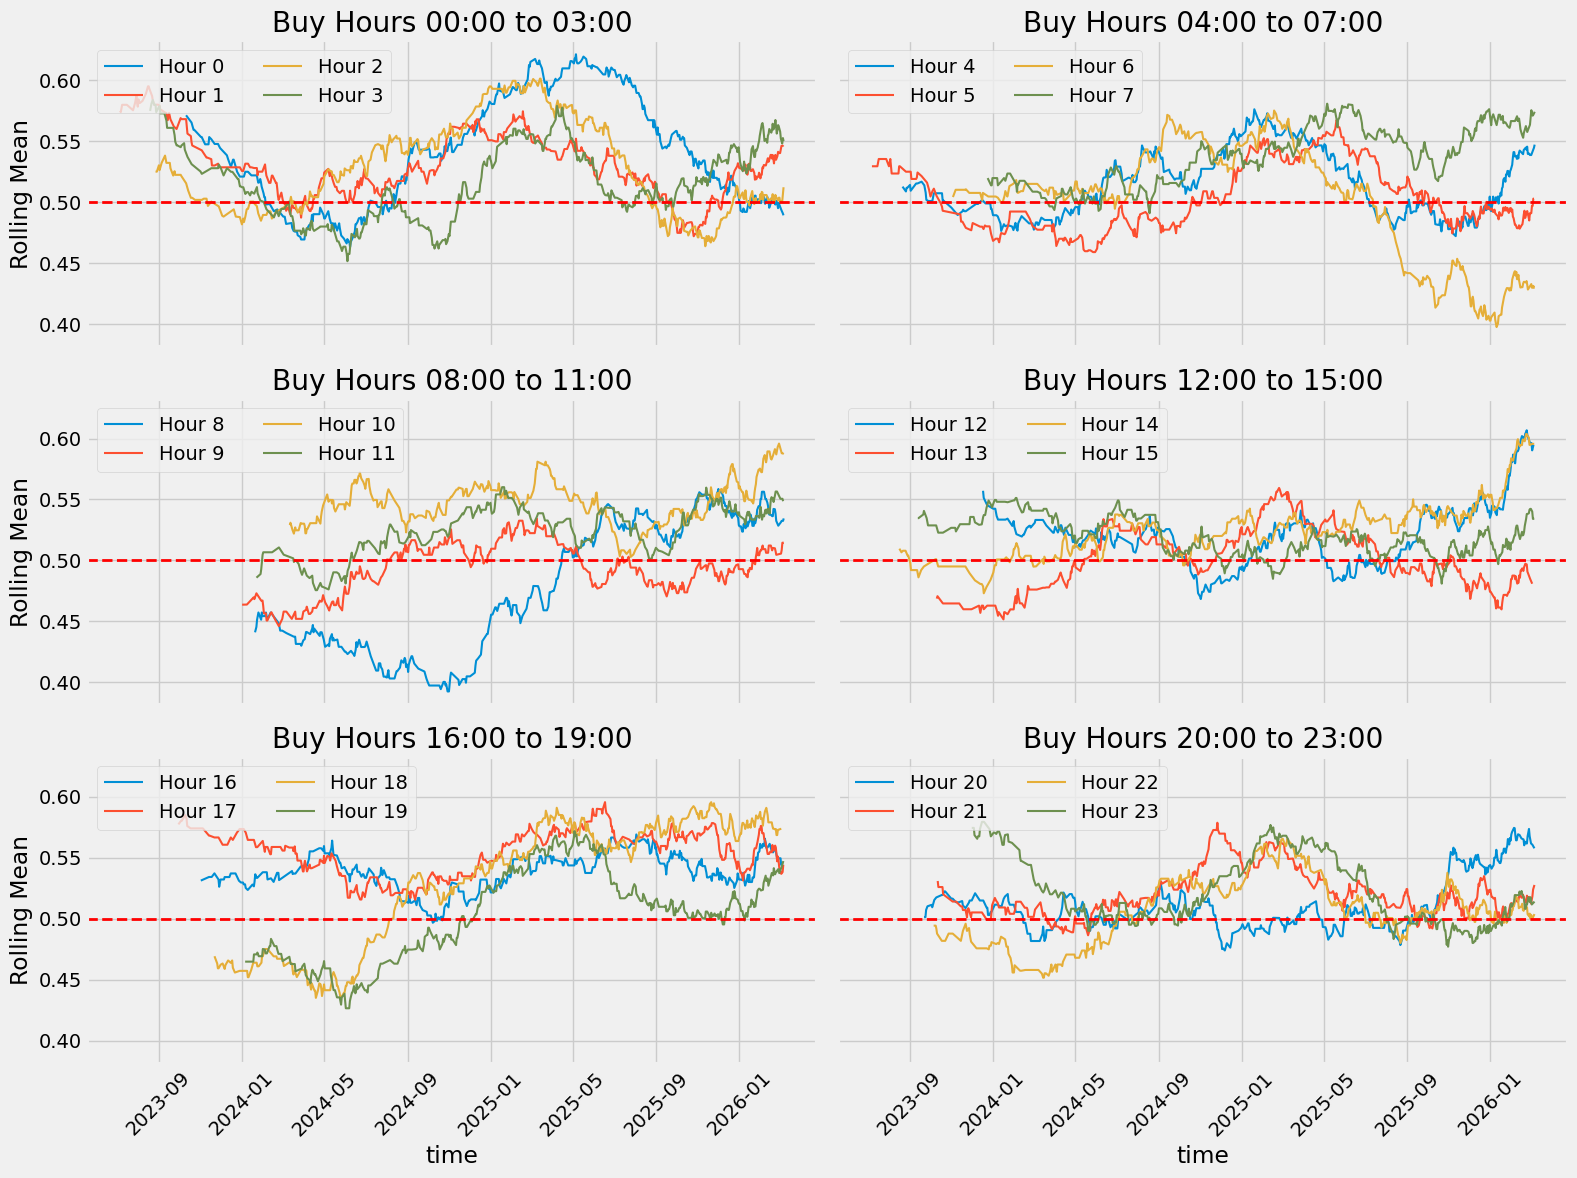

In [17]:
# Pivot the data
pvt = train_buy.loc[(train_buy["time"] < test_date), ["time", "target"]]
pvt["hour"] = pvt["time"].dt.hour
pvt = pvt.pivot_table(
    index="time", columns="hour", values="target", aggfunc="mean"
)

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i in range(6):
    ax = axes[i]
    start_hour = i * 4
    end_hour = start_hour + 3

    # Plot each of the 4 hours designated for this subplot
    for hour in range(start_hour, end_hour + 1):
        if hour in pvt.columns:  # Check to ensure the hour exists in the data
            tmp = pvt[hour].dropna().rolling(window=168).mean()
            sns.lineplot(
                data=tmp, ax=ax, label=f"Hour {hour}", linewidth=1.5, legend="brief"
            )

    # Add the horizontal reference line to the current subplot
    ax.axhline(y=0.5, color="red", linestyle="--", linewidth=2)

    # Customize the current subplot
    ax.set_title(f"Buy Hours {start_hour:02d}:00 to {end_hour:02d}:00")
    ax.set_ylabel("Rolling Mean")
    ax.legend(loc="upper left", ncol=2)  # 2-column legend to save space
    ax.tick_params(axis="x", labelrotation=45)

# Adjust the layout to prevent titles/labels from overlapping
plt.tight_layout()
plt.show()

### Look for profitable buy hours using Rolling Mean (RM)

In [18]:
results = []

for hour in range(24):
    if hour in pvt.columns:
        rolling_series = pvt[hour].dropna().rolling(window=168).mean()
        valid_rolling = rolling_series.dropna()

        if len(valid_rolling) > 0:
            pct_above = (valid_rolling > 0.5).mean() * 100
            pct_max = valid_rolling.max()
            pct_min = valid_rolling.min()
        else:
            pct_above = np.nan
    else:
        pct_above = np.nan

    results.append({
        "hour": hour, 
        "percent_above_0_5": pct_above, 
        "pct_min": pct_min,
        "pct_max": pct_max,
        })

# Create the final DataFrame
summary_buy_df = pd.DataFrame(results)

# Optional: Format the percentage to 2 decimal places for better readability
summary_buy_df[["percent_above_0_5", "pct_min", "pct_max"]] = summary_buy_df[["percent_above_0_5", "pct_min", "pct_max"]].round(2)

print(summary_buy_df.sort_values("percent_above_0_5", ascending=False))

    hour  percent_above_0_5  pct_min  pct_max
17    17             100.00     0.52     0.60
10    10             100.00     0.50     0.60
16    16              98.74     0.50     0.57
7      7              95.88     0.49     0.58
14    14              91.24     0.47     0.60
15    15              91.23     0.48     0.55
11    11              90.24     0.48     0.56
21    21              90.00     0.49     0.58
1      1              86.01     0.47     0.60
12    12              78.13     0.47     0.61
0      0              77.16     0.46     0.62
18    18              76.04     0.43     0.60
2      2              73.66     0.46     0.60
23    23              70.05     0.48     0.58
3      3              69.96     0.45     0.58
20    20              67.13     0.47     0.57
22    22              65.42     0.45     0.57
19    19              64.99     0.43     0.57
6      6              63.74     0.40     0.58
4      4              62.02     0.47     0.58
8      8              48.47     0.

### Visualize sell hours distribution

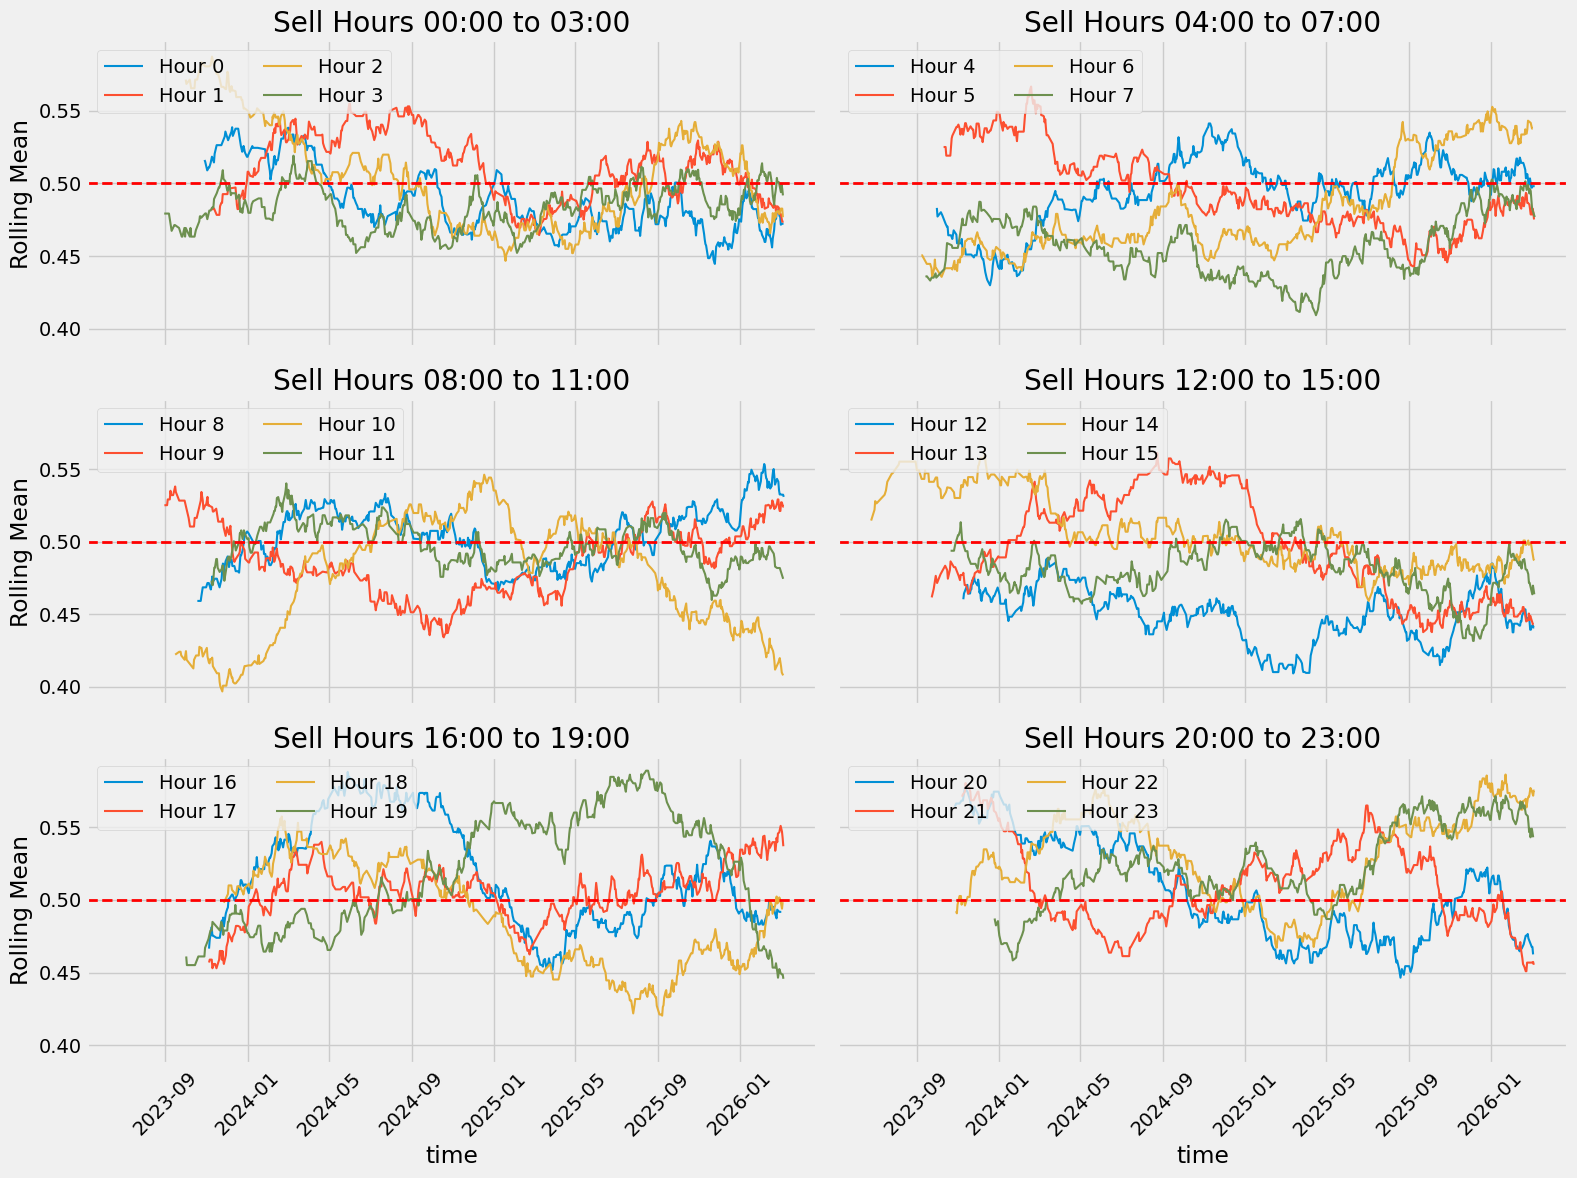

In [19]:
# Pivot the data
pvt = train_sell.loc[(train_sell["time"] < test_date), ["time", "target"]]
pvt["hour"] = pvt["time"].dt.hour
pvt = pvt.pivot_table(
    index="time", columns="hour", values="target", aggfunc="mean"
)

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 12), sharex=True, sharey=True)
axes = axes.flatten()

# Loop through the 6 subplots
for i in range(6):
    ax = axes[i]
    start_hour = i * 4
    end_hour = start_hour + 3

    # Plot each of the 4 hours designated for this subplot
    for hour in range(start_hour, end_hour + 1):
        if hour in pvt.columns:  # Check to ensure the hour exists in the data
            tmp = pvt[hour].dropna().rolling(window=168).mean()
            sns.lineplot(
                data=tmp, ax=ax, label=f"Hour {hour}", linewidth=1.5, legend="brief"
            )

    # Add the horizontal reference line to the current subplot
    ax.axhline(y=0.5, color="red", linestyle="--", linewidth=2)

    # Customize the current subplot
    ax.set_title(f"Sell Hours {start_hour:02d}:00 to {end_hour:02d}:00")
    ax.set_ylabel("Rolling Mean")
    ax.legend(loc="upper left", ncol=2)  # 2-column legend to save space
    ax.tick_params(axis="x", labelrotation=45)

# Adjust the layout to prevent titles/labels from overlapping
plt.tight_layout()
plt.show()

### Look for profitable sell hours using Rolling Mean (RM)

In [20]:
results = []

for hour in range(24):
    if hour in pvt.columns:
        rolling_series = pvt[hour].dropna().rolling(window=168).mean()
        valid_rolling = rolling_series.dropna()

        if len(valid_rolling) > 0:
            pct_above = (valid_rolling > 0.5).mean() * 100
            pct_max = valid_rolling.max()
            pct_min = valid_rolling.min()
        else:
            pct_above = np.nan
    else:
        pct_above = np.nan

    results.append({
        "hour": hour, 
        "percent_above_0_5": pct_above, 
        "pct_min": pct_min,
        "pct_max": pct_max,
        })

# Create the final DataFrame
summary_sell_df = pd.DataFrame(results)

# Optional: Format the percentage to 2 decimal places for better readability
summary_sell_df[["percent_above_0_5", "pct_min", "pct_max"]] = summary_sell_df[["percent_above_0_5", "pct_min", "pct_max"]].round(2)

print(summary_sell_df.sort_values("percent_above_0_5", ascending=False))

    hour  percent_above_0_5  pct_min  pct_max
23    23              86.11     0.46     0.57
22    22              79.83     0.47     0.59
17    17              68.75     0.45     0.55
1      1              64.51     0.46     0.55
19    19              63.56     0.45     0.59
8      8              62.75     0.46     0.55
16    16              60.59     0.45     0.59
21    21              58.28     0.45     0.58
2      2              54.08     0.45     0.59
4      4              49.81     0.43     0.54
20    20              47.15     0.45     0.58
14    14              45.35     0.46     0.56
11    11              43.25     0.46     0.54
13    13              40.08     0.44     0.56
18    18              38.28     0.42     0.56
10    10              35.68     0.40     0.55
9      9              34.82     0.43     0.54
5      5              34.50     0.44     0.57
6      6              26.69     0.44     0.55
0      0              22.86     0.44     0.54
3      3              20.33     0.

Let's select sell hours with avg profitable ratio >= 0.6 and intersect them with previously selected hours to sell

### Save profitable hours

In [21]:
os.makedirs("data", exist_ok=True)

RM_percent_above_0_5 = 60

profitable_buy_hours_RM = summary_buy_df.query("percent_above_0_5 >= @RM_percent_above_0_5")["hour"].tolist()
# intersect profitable_hours with buy hours to save
profitable_buy_hours = sorted(list(set(profitable_buy_hours_RM).intersection(set(profitable_buy_hours_TI))))

profitable_sell_hours_RM = summary_sell_df.query("percent_above_0_5 >= @RM_percent_above_0_5")["hour"].tolist()
# intersect profitable_hours with sell hours to save
profitable_sell_hours = sorted(list(set(profitable_sell_hours_RM).intersection(set(profitable_sell_hours_TI))))


pkl_path = "data/profitable_hours.csv"
new_row = pd.DataFrame([{
    "time": datetime.now(),
    "test_date": test_date,
    "TI_low_bound": TI_low_bound,
    "RM_percent_above_0_5": RM_percent_above_0_5,
    "profitable_buy_hours_RM": profitable_buy_hours_RM,
    "profitable_buy_hours_TI": profitable_buy_hours_TI,
    "profitable_buy_hours": profitable_buy_hours,
    "profitable_sell_hours_RM": profitable_sell_hours_RM,
    "profitable_sell_hours_TI": profitable_sell_hours_TI,
    "profitable_sell_hours": profitable_sell_hours,
}])

if os.path.exists(pkl_path):
    profitable_hours_df = pd.read_csv(pkl_path)
    profitable_hours_df = pd.concat([profitable_hours_df, new_row], ignore_index=True)
else:
    profitable_hours_df = new_row

profitable_hours_df.to_csv(pkl_path, index=False)
profitable_hours_df[[c for c in profitable_hours_df.columns if c not in ["time"]]]

,test_date,TI_low_bound,RM_percent_above_0_5,profitable_buy_hours_RM,profitable_buy_hours_TI,profitable_buy_hours,profitable_sell_hours_RM,profitable_sell_hours_TI,profitable_sell_hours
0,2026-03-06 12:00:00,0.495,60,"[0, 1, 2, 3, 4, 6, 7, 10, 11, 12, 14, 15, 16, ...","[0, 1, 2, 3, 4, 5, 6, 7, 10, 11, 14, 15, 16, 1...","[0, 1, 2, 3, 4, 6, 7, 10, 11, 14, 15, 16, 17, ...","[1, 2, 8, 11, 14, 16, 17, 19, 21, 22, 23]","[8, 9, 13, 14, 15, 16, 17, 19]","[8, 14, 16, 17, 19]"
1,2026-03-06 12:00:00,0.495,60,"[0, 1, 2, 3, 4, 6, 7, 10, 11, 12, 14, 15, 16, ...","[0, 1, 2, 3, 4, 5, 6, 7, 10, 11, 14, 15, 16, 1...","[0, 1, 2, 3, 4, 6, 7, 10, 11, 14, 15, 16, 17, ...","[1, 2, 8, 11, 14, 16, 17, 19, 21, 22, 23]","[8, 9, 13, 15, 16, 17, 19]","[8, 16, 17, 19]"
2,2026-03-07 11:00:00,0.495,60,"[0, 1, 2, 3, 4, 6, 7, 10, 11, 12, 14, 15, 16, ...","[0, 1, 2, 3, 4, 5, 6, 7, 10, 11, 14, 15, 16, 1...","[0, 1, 2, 3, 4, 6, 7, 10, 11, 14, 15, 16, 17, ...","[1, 8, 17, 19, 22, 23]","[8, 9, 13, 15]",[8]
3,2026-03-07 11:00:00,0.495,60,"[0, 1, 2, 3, 4, 6, 7, 10, 11, 12, 14, 15, 16, ...","[0, 1, 2, 3, 4, 5, 6, 7, 10, 11, 14, 15, 16, 1...","[0, 1, 2, 3, 4, 6, 7, 10, 11, 14, 15, 16, 17, ...","[1, 8, 16, 17, 19, 22, 23]","[8, 9, 13, 15]",[8]


# Data visualization

### Plot ratio of class 1 for every week day

Monday = 0, Sunday = 6

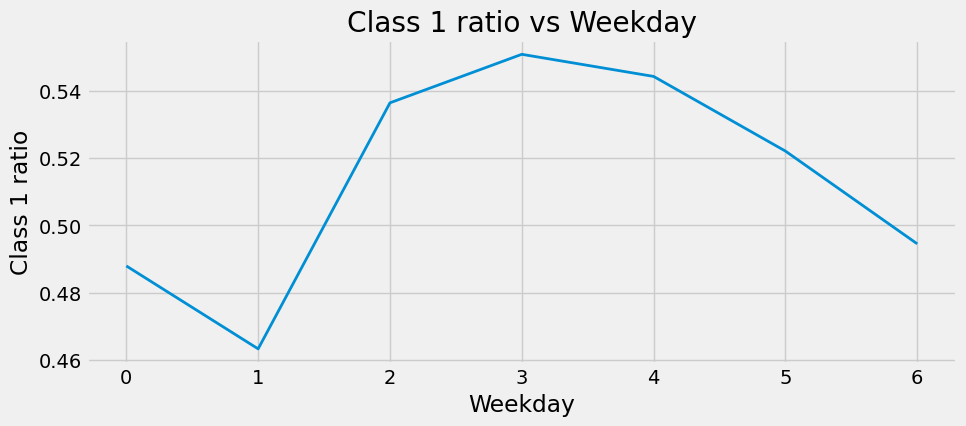

In [22]:
plt.figure(figsize=(10, 4))

group_df = train_df[(train_df["time"].dt.year >= 2020)]
group_df["weekday"] = group_df["time"].dt.weekday
ax = group_df.groupby("weekday")["target"].mean().plot()
ax.lines[0].set_linewidth(2)
ax.set_xlabel("Weekday")
ax.set_ylabel("Class 1 ratio")
ax.set_title("Class 1 ratio vs Weekday");

### Plot ratio of class 1 for every month

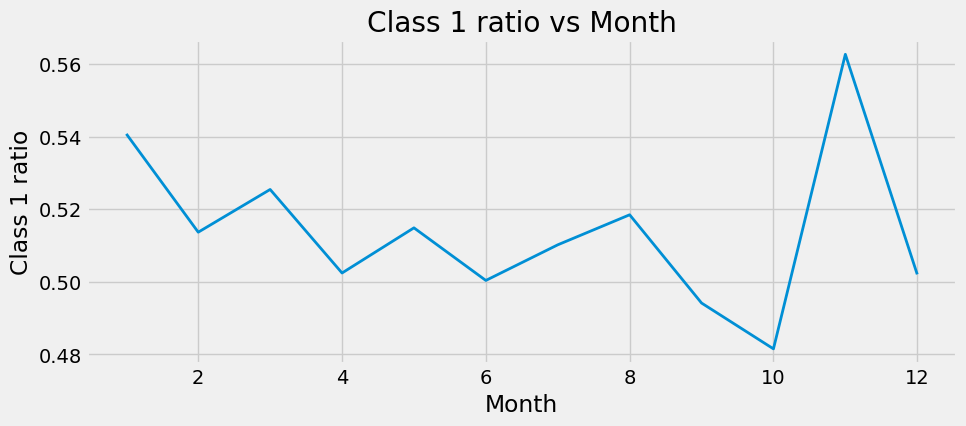

In [23]:
plt.figure(figsize=(10, 4))

group_df = train_df[(train_df["time"].dt.year >= 2020)]
group_df["month"] = group_df["time"].dt.month
ax = group_df.groupby("month")["target"].mean().plot()
ax.lines[0].set_linewidth(2)
ax.set_xlabel("Month")
ax.set_ylabel("Class 1 ratio")
ax.set_title("Class 1 ratio vs Month");

### Visualize buy trades

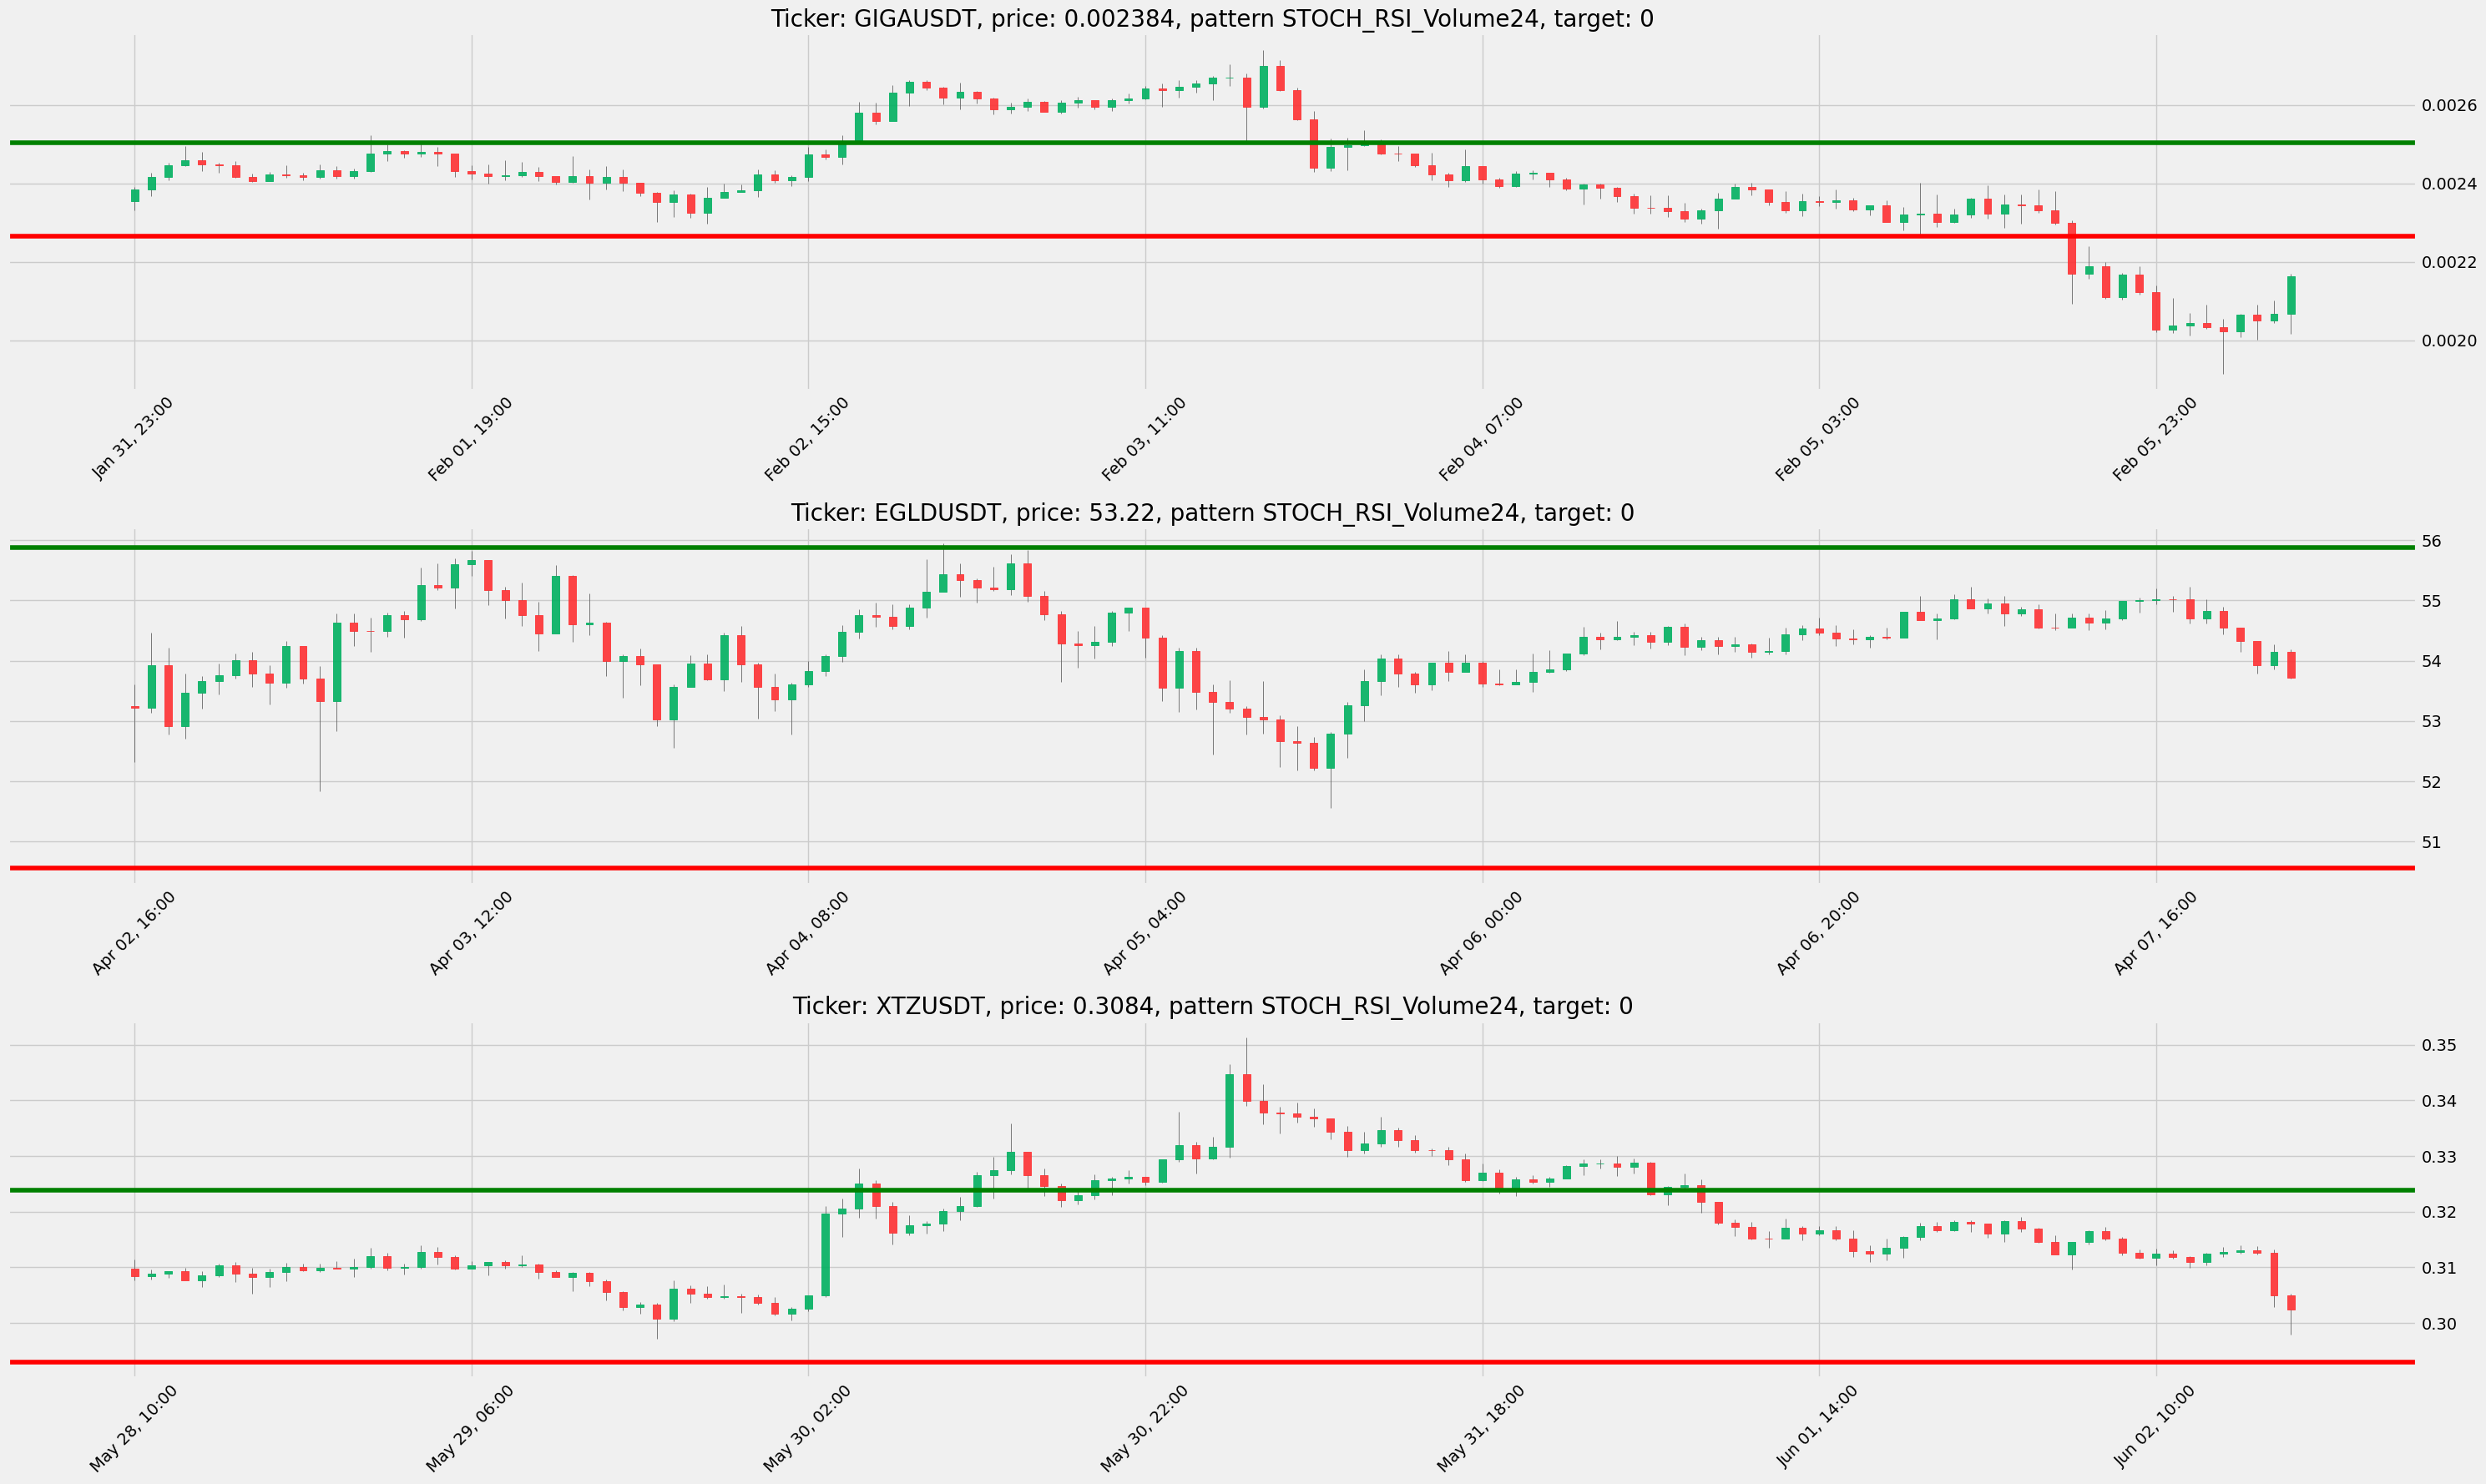

In [24]:
import matplotlib.pyplot as plt
import mplfinance as mpf

if CFG.create_dataset:
    plt_num = 3
    j = 1
    fig = plt.figure(figsize=(30, 6 * plt_num))

    buy_idxs = train_buy.index
    test_buy = train_buy.sample(plt_num, axis=0)


    for i, row in test_buy.iterrows():
        ticker = row["ticker"]
        time = row["time"]
        target = row["target"]
        ttype = row["ttype"]
        pattern = row["pattern"]

        df_1h, _ = get_file(ticker)
        df_1h = df_1h[(df_1h["time"] >= time) & (df_1h["time"] <= time + timedelta(hours=CFG.target_offset))]

        ohlc = df_1h[["time", "open", "high", "low", "close", "volume"]].set_index("time")
        
        price = df_1h.iloc[0]["close"]
        high_price = price * CFG.cls_target_ratio_sl
        low_price = price * (2 - CFG.cls_target_ratio_tp)

        ax = fig.add_subplot(plt_num, 1, j)
        mpf.plot(ohlc, type="candle", warn_too_much_data=1001, style="yahoo", ylabel="", tz_localize=True, ax=ax)
        
        if ttype == "buy":
            ax.axhline(high_price, color="g")
            ax.axhline(low_price, color="r")
        else:
            ax.axhline(high_price, color="r")
            ax.axhline(low_price, color="g")
        ax.set_title(f"Ticker: {ticker}, price: {price}, pattern {pattern}, target: {target}", fontsize=20)
        j += 1
        
    fig.tight_layout()

### Visualize sell trades

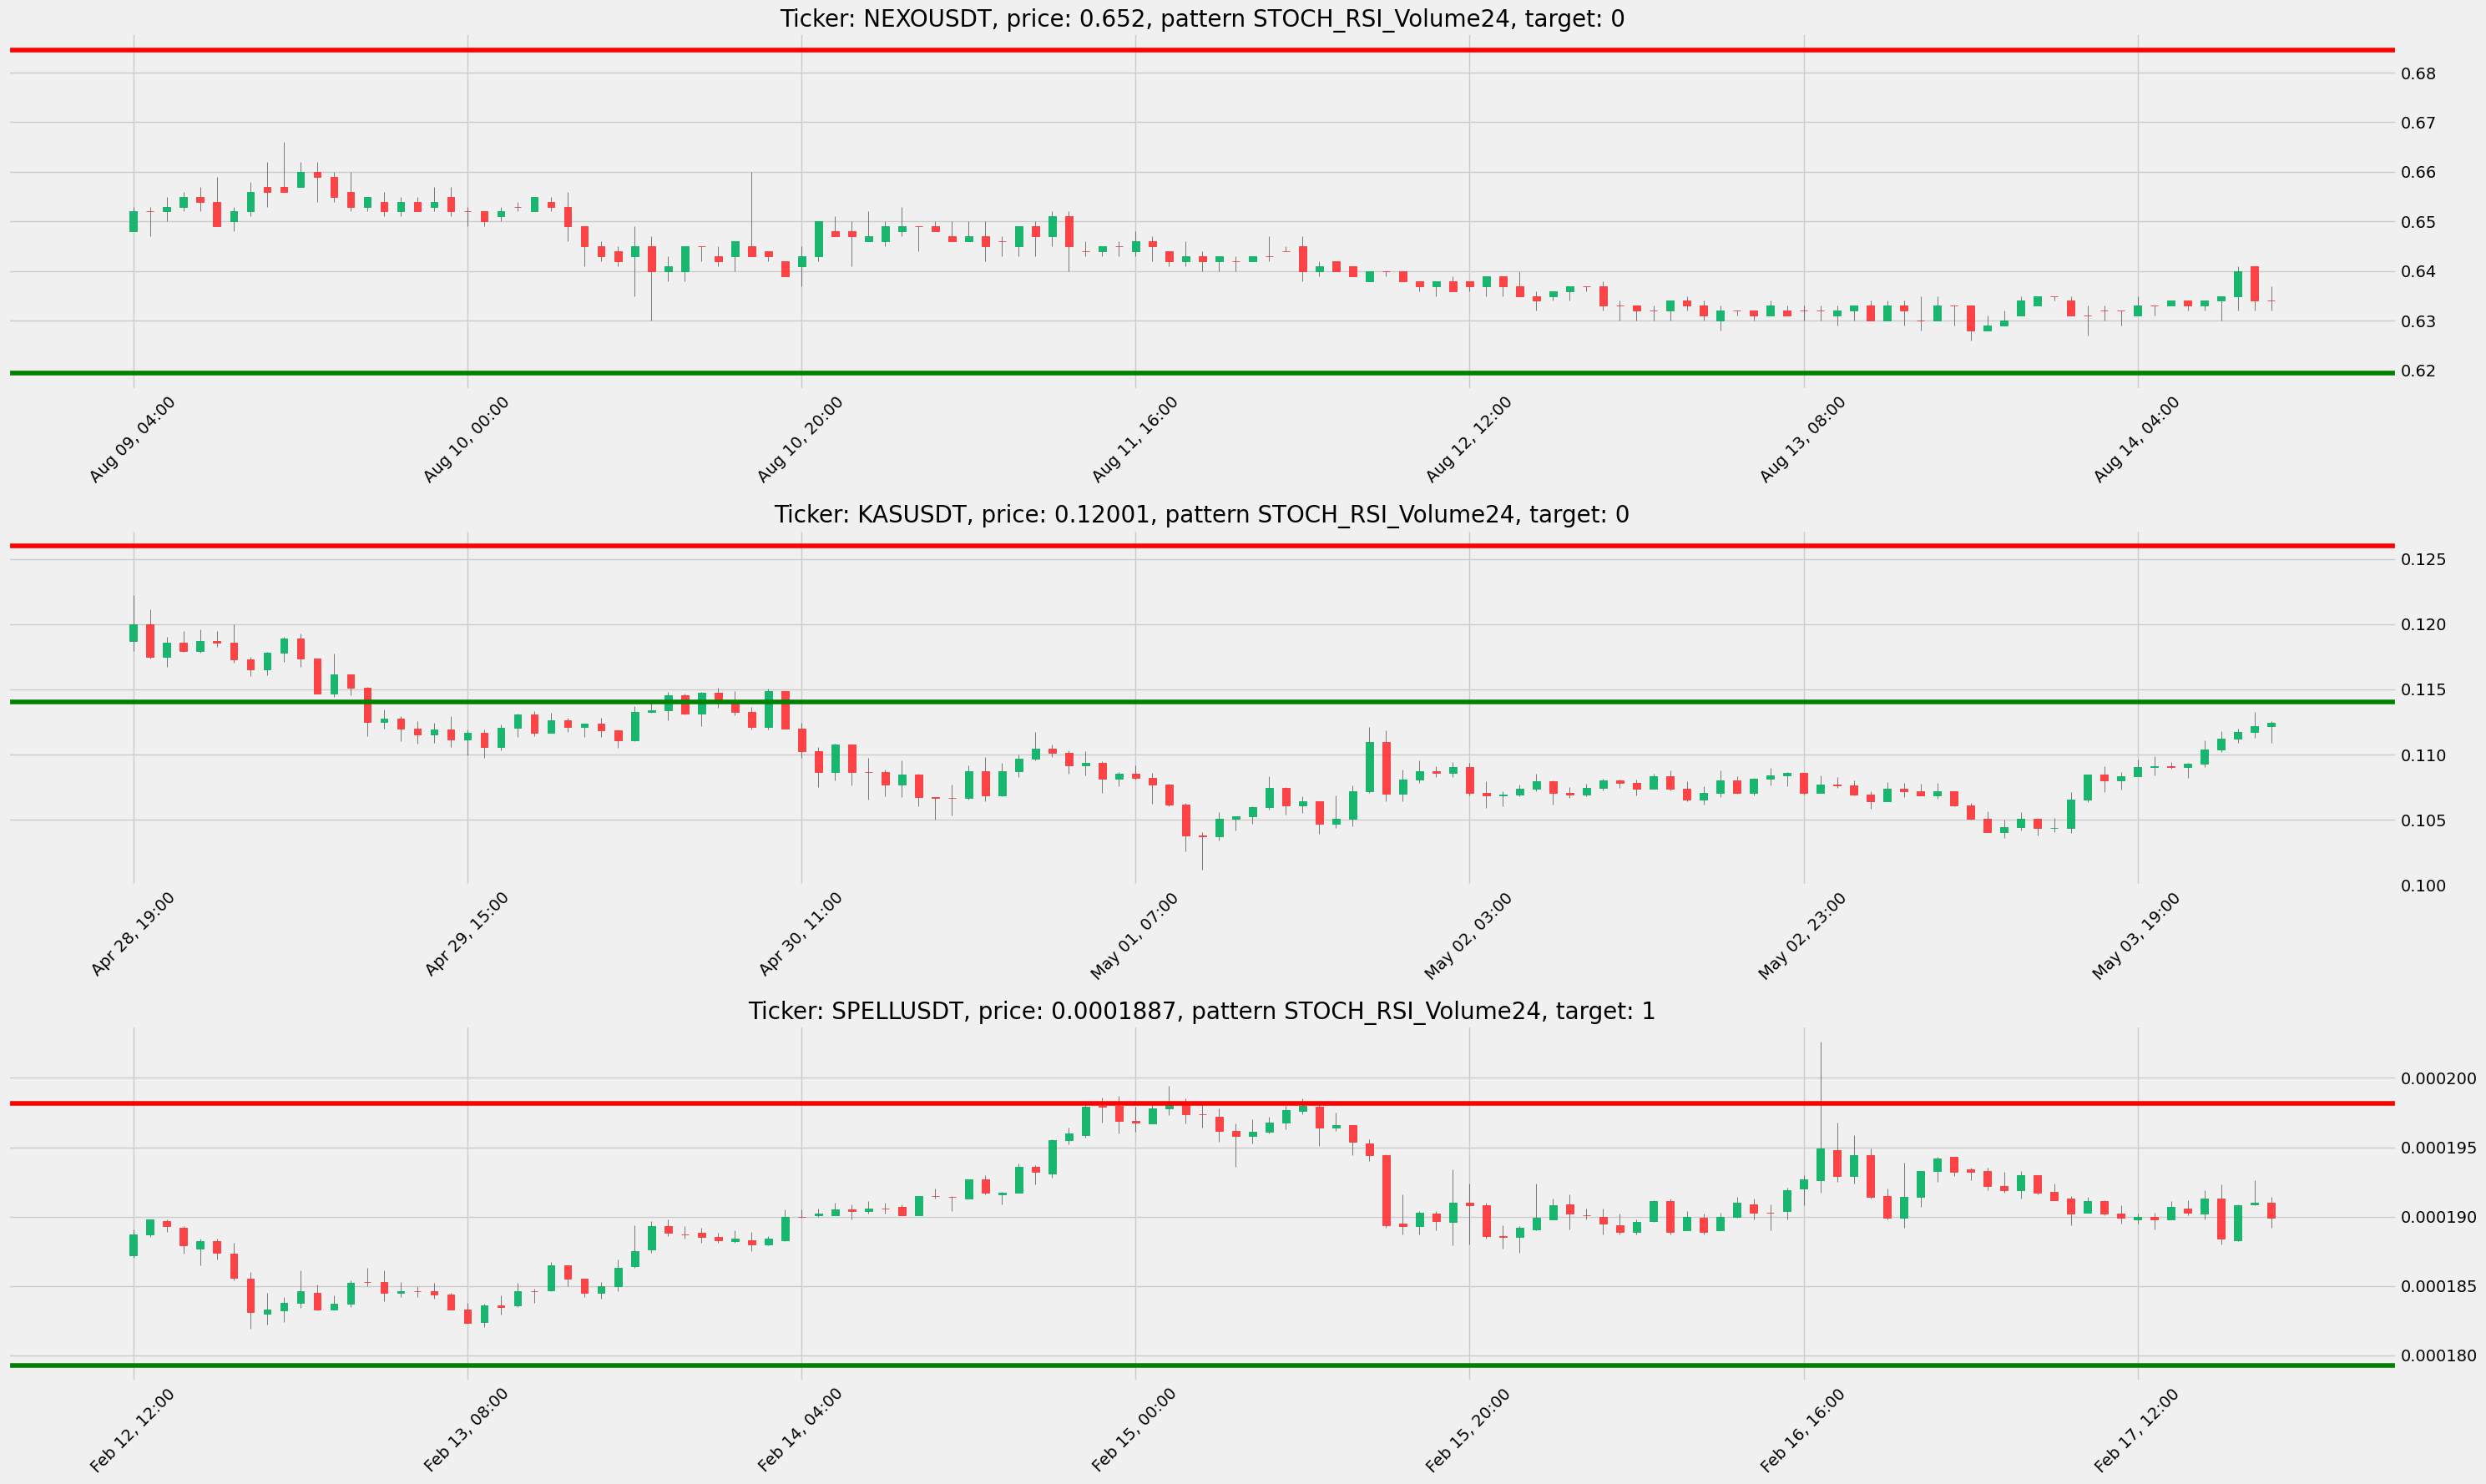

In [25]:
if CFG.create_dataset:
    plt_num = 3
    j = 1
    fig = plt.figure(figsize=(30, 6 * plt_num))

    buy_idxs = train_sell.index
    test_sell = train_sell.sample(plt_num, axis=0)

    for i, row in test_sell.iterrows():
        ticker = row["ticker"]
        time = row["time"]
        target = row["target"]
        ttype = row["ttype"]
        pattern = row["pattern"]

        df_1h, _ = get_file(ticker)
        df_1h = df_1h[(df_1h["time"] >= time) & (df_1h["time"] <= time + timedelta(hours=CFG.target_offset))]
        
        ohlc = df_1h[["time", "open", "high", "low", "close", "volume"]].set_index("time")
        
        price = df_1h.iloc[0]["close"]
        high_price = price * CFG.cls_target_ratio_tp
        low_price = price * (2 - CFG.cls_target_ratio_sl)

        ax = fig.add_subplot(plt_num, 1, j)
        mpf.plot(ohlc, type="candle", warn_too_much_data=1001, style="yahoo", ylabel="", tz_localize=True, ax=ax)
        
        if ttype == "buy":
            ax.axhline(high_price, color="g")
            ax.axhline(low_price, color="r")
        else:
            ax.axhline(high_price, color="r")
            ax.axhline(low_price, color="g")
        ax.set_title(f"Ticker: {ticker}, price: {price}, pattern {pattern}, target: {target}", fontsize=20)
        j += 1
        
    fig.tight_layout()

### Show the last signals

In [26]:
x = pd.read_pickle("data/signal_stat/buy_stat_1h.pkl")
x["ttype"] = "buy"
y = pd.read_pickle("data/signal_stat/sell_stat_1h.pkl")
y["ttype"] = "sell"
x = pd.concat([x, y]).sort_values("time").reset_index(drop=True)
x.loc[x["pattern"] == "STOCH_RSI_Volume24", ["time", "ticker", "ttype", "pattern"]].tail(20)

,time,ticker,ttype,pattern
171848,2026-06-05 14:00:00,SKRUSDT,sell,STOCH_RSI_Volume24
171849,2026-06-05 14:00:00,RESOLVUSDT,sell,STOCH_RSI_Volume24
171850,2026-06-05 14:00:00,FARTCOINUSDT,buy,STOCH_RSI_Volume24
171851,2026-06-05 14:00:00,PUNDIXUSDT,sell,STOCH_RSI_Volume24
171852,2026-06-05 14:00:00,PORTALUSDT,sell,STOCH_RSI_Volume24
171853,2026-06-05 14:00:00,DODOXUSDT,buy,STOCH_RSI_Volume24
171854,2026-06-05 14:00:00,IDUSDT,sell,STOCH_RSI_Volume24
171855,2026-06-05 14:00:00,TAIKOUSDT,buy,STOCH_RSI_Volume24
171856,2026-06-05 15:00:00,KNCUSDT,buy,STOCH_RSI_Volume24
171857,2026-06-05 15:00:00,KNCUSDT,sell,STOCH_RSI_Volume24


# Save train data

In [27]:
train_df.to_pickle("data/train_df.pkl")